In [2]:
!pip install prophet

  Using cached prophet-1.3.0-py3-none-win_amd64.whl.metadata (3.6 kB)
  Using cached cmdstanpy-1.3.0-py3-none-any.whl.metadata (4.2 kB)
  Using cached holidays-0.91-py3-none-any.whl.metadata (50 kB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl.metadata (3.9 kB)
  Using cached stanio-0.5.1-py3-none-any.whl.metadata (1.6 kB)
Using cached prophet-1.3.0-py3-none-win_amd64.whl (12.1 MB)
Using cached cmdstanpy-1.3.0-py3-none-any.whl (99 kB)
Using cached holidays-0.91-py3-none-any.whl (1.4 MB)
Using cached importlib_resources-6.5.2-py3-none-any.whl (37 kB)
Using cached stanio-0.5.1-py3-none-any.whl (8.1 kB)


1. Membaca dataset asli...
2. Dataset dibaca! Total ada 298 anak.
3. Mulai mengevaluasi seluruh anak per indikator. Mohon tunggu...


10:52:50 - cmdstanpy - INFO - Chain [1] start processing
10:52:50 - cmdstanpy - INFO - Chain [1] done processing


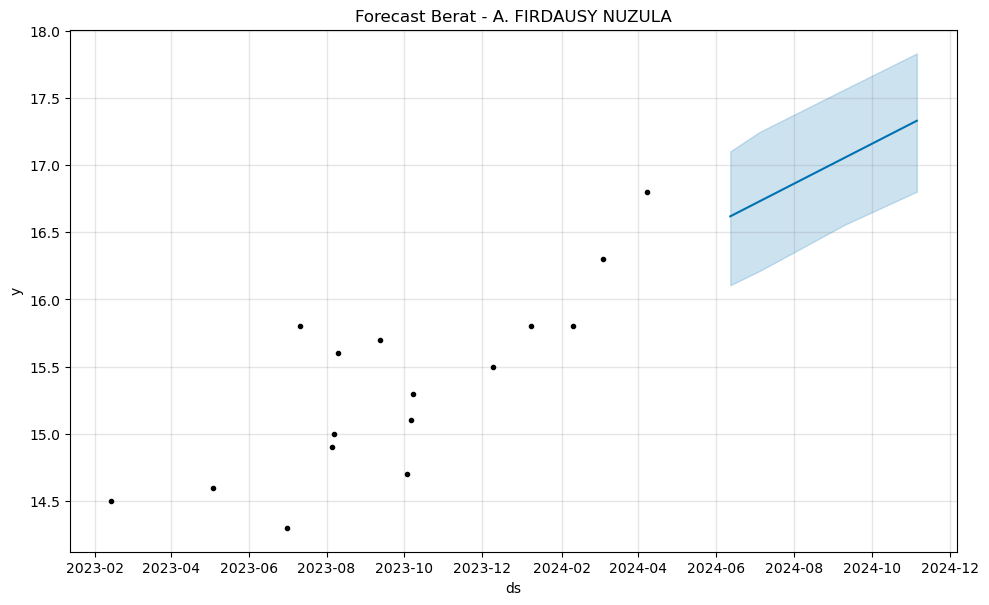

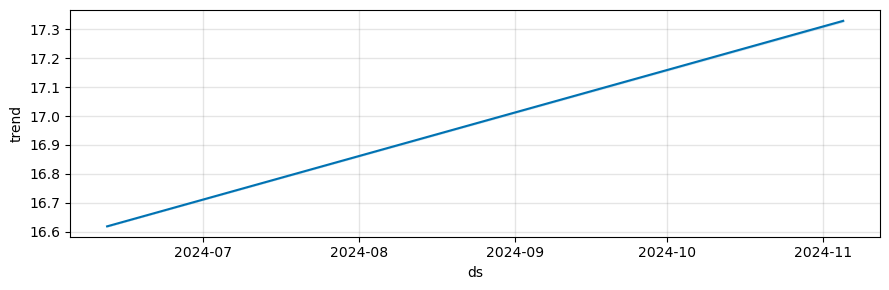

10:52:52 - cmdstanpy - INFO - Chain [1] start processing
10:52:52 - cmdstanpy - INFO - Chain [1] done processing


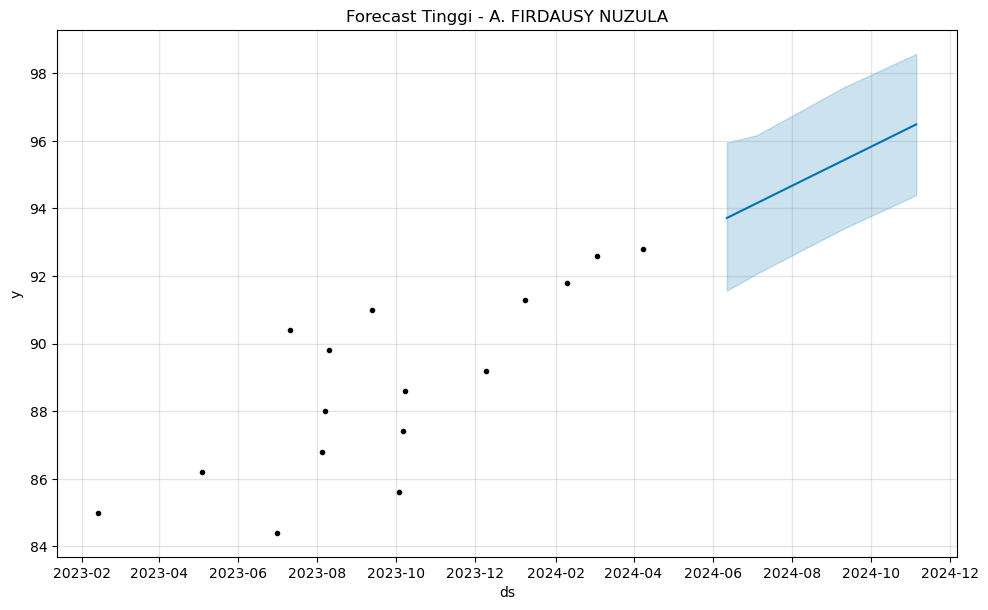

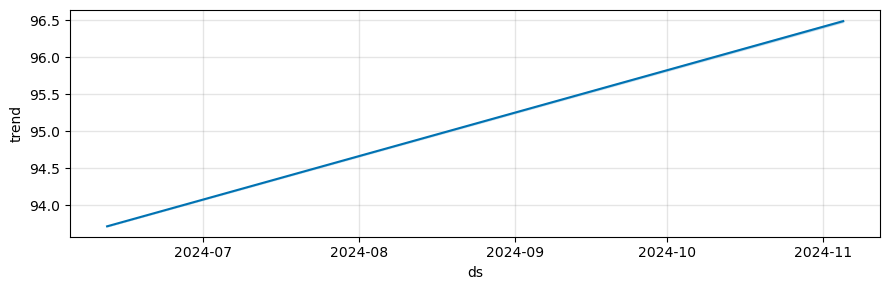

10:52:52 - cmdstanpy - INFO - Chain [1] start processing
10:52:52 - cmdstanpy - INFO - Chain [1] done processing


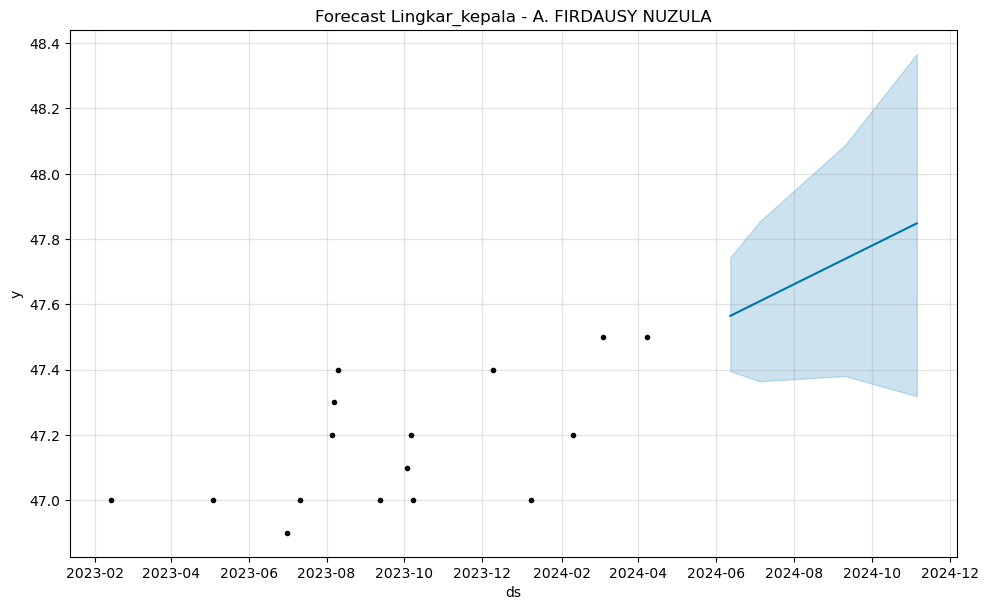

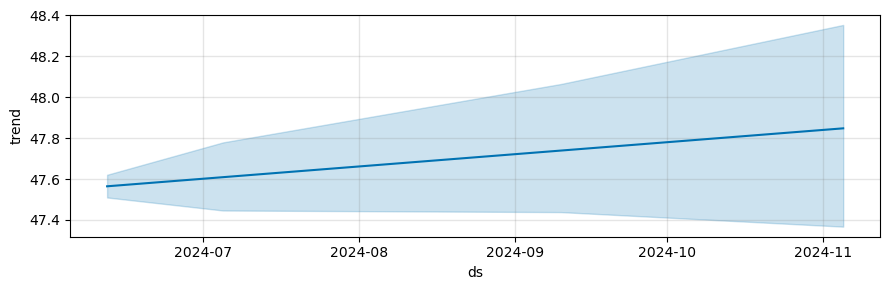

10:52:54 - cmdstanpy - INFO - Chain [1] start processing
10:52:54 - cmdstanpy - INFO - Chain [1] done processing


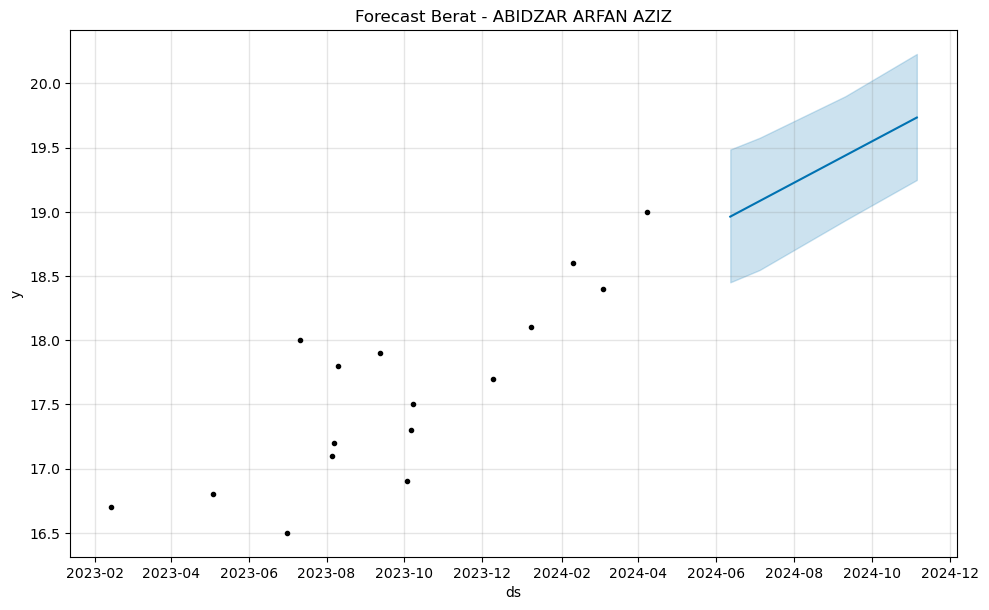

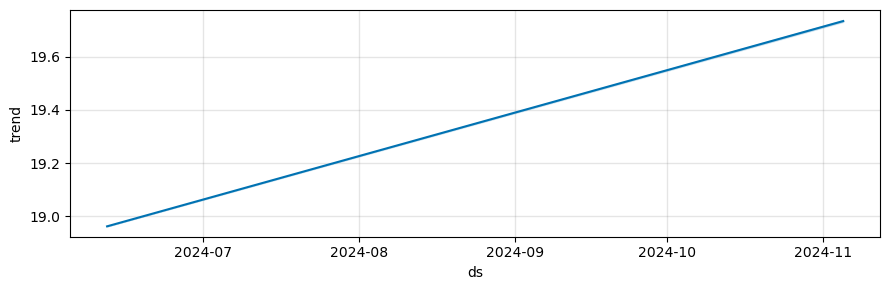

10:52:55 - cmdstanpy - INFO - Chain [1] start processing
10:52:55 - cmdstanpy - INFO - Chain [1] done processing


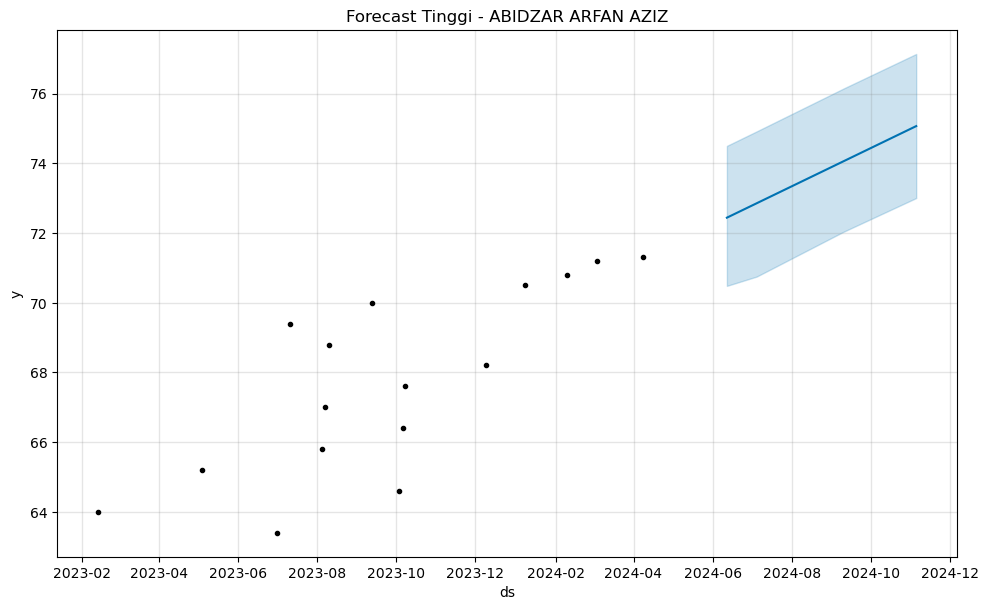

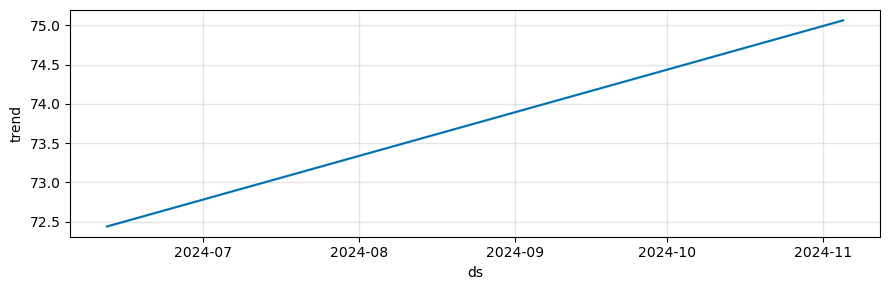

10:52:55 - cmdstanpy - INFO - Chain [1] start processing
10:52:55 - cmdstanpy - INFO - Chain [1] done processing


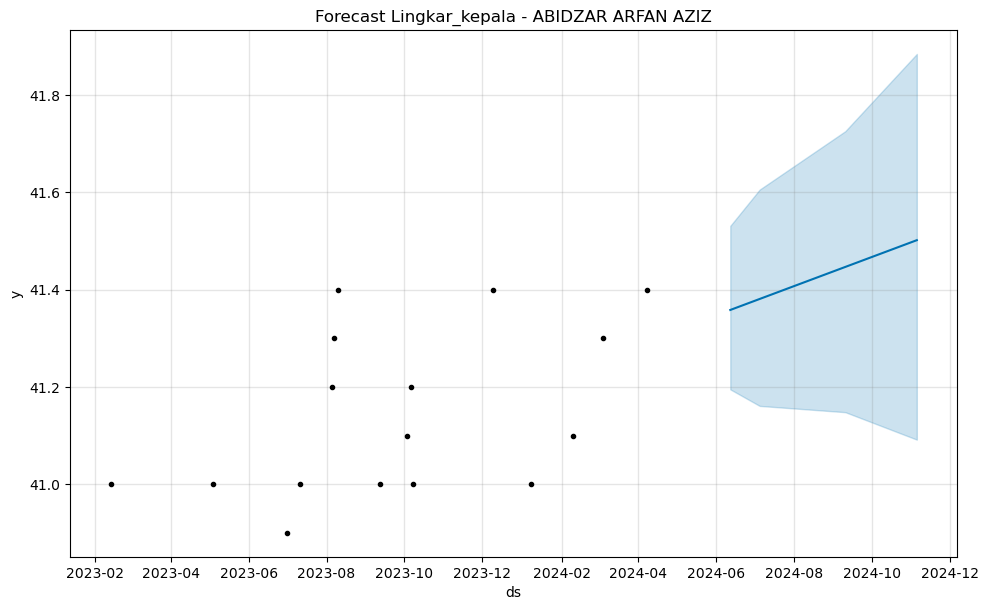

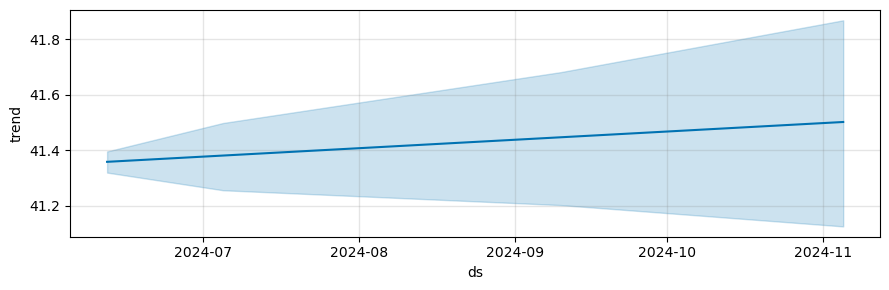

10:52:56 - cmdstanpy - INFO - Chain [1] start processing
10:52:56 - cmdstanpy - INFO - Chain [1] done processing


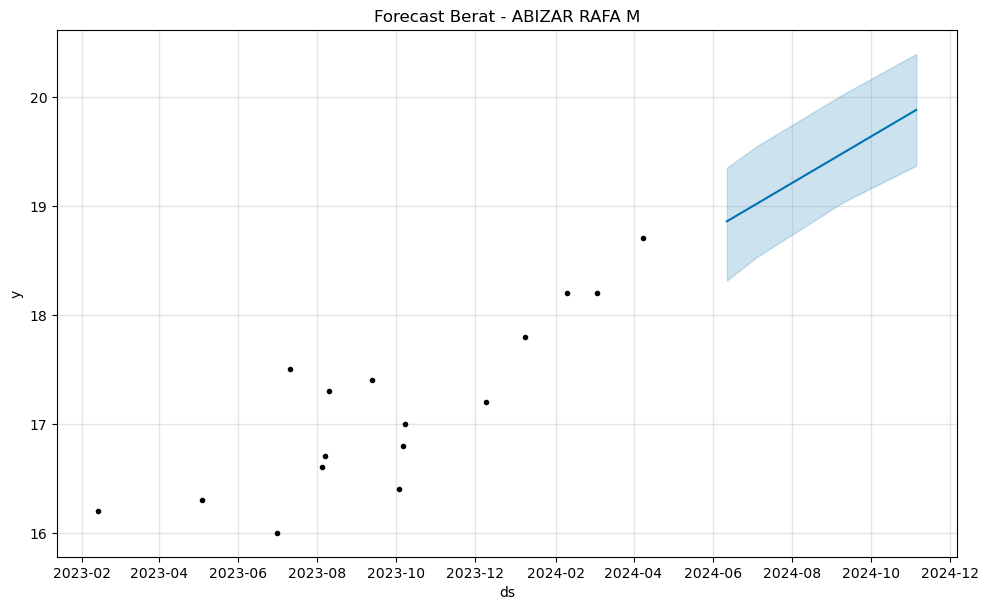

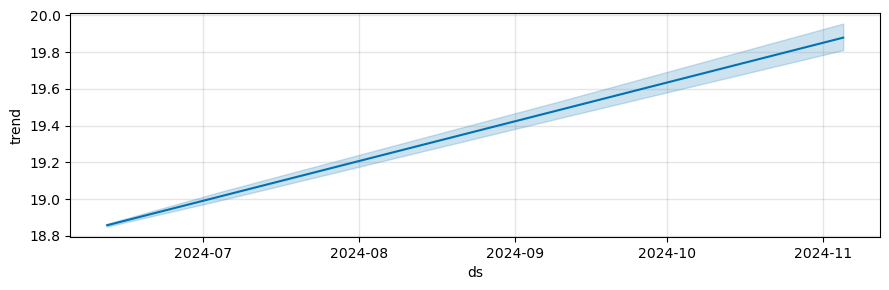

10:52:57 - cmdstanpy - INFO - Chain [1] start processing
10:52:57 - cmdstanpy - INFO - Chain [1] done processing


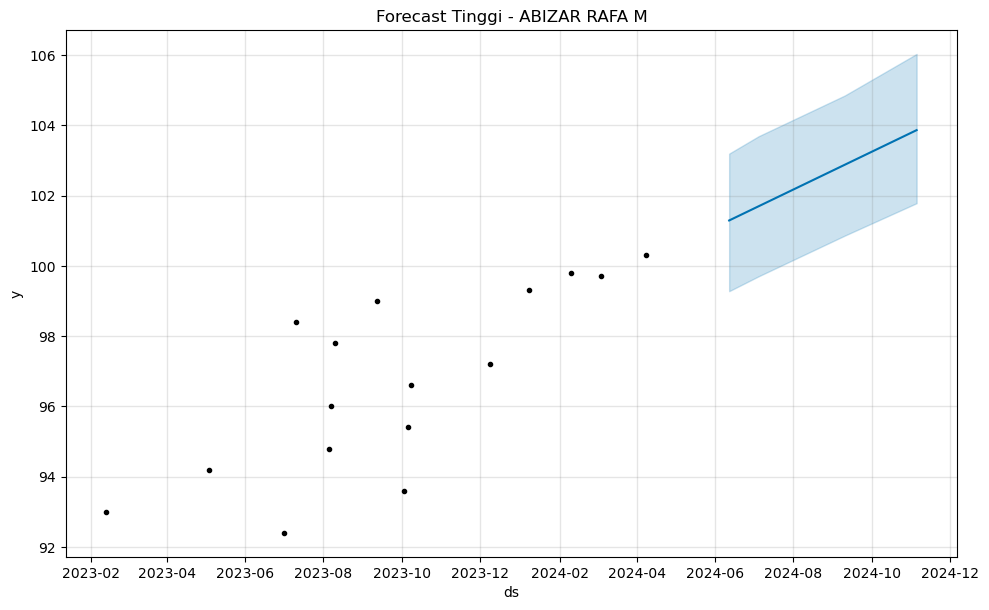

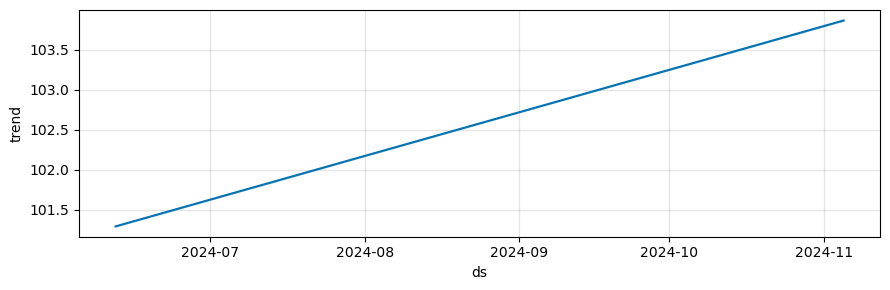

10:52:58 - cmdstanpy - INFO - Chain [1] start processing
10:52:58 - cmdstanpy - INFO - Chain [1] done processing


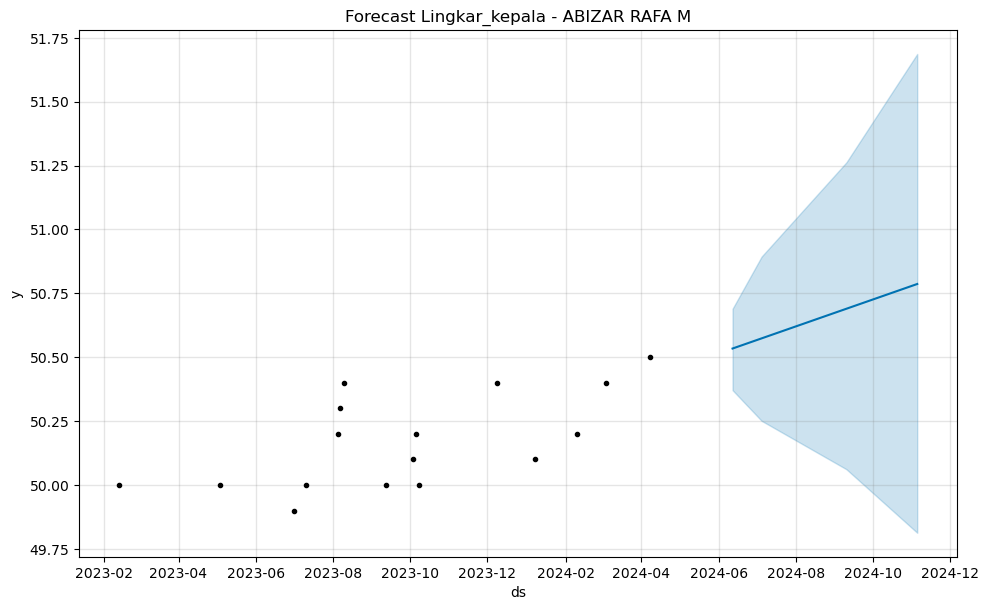

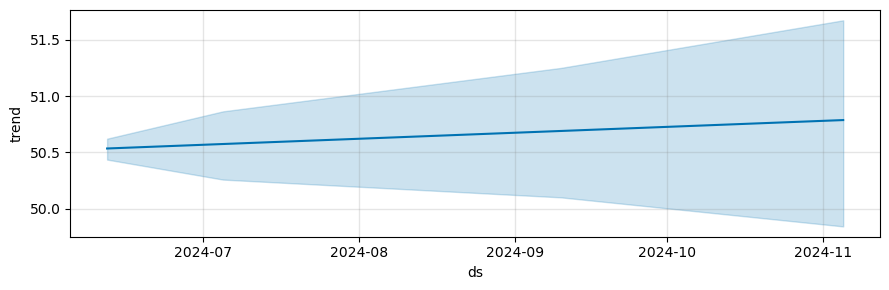

10:52:59 - cmdstanpy - INFO - Chain [1] start processing
10:52:59 - cmdstanpy - INFO - Chain [1] done processing


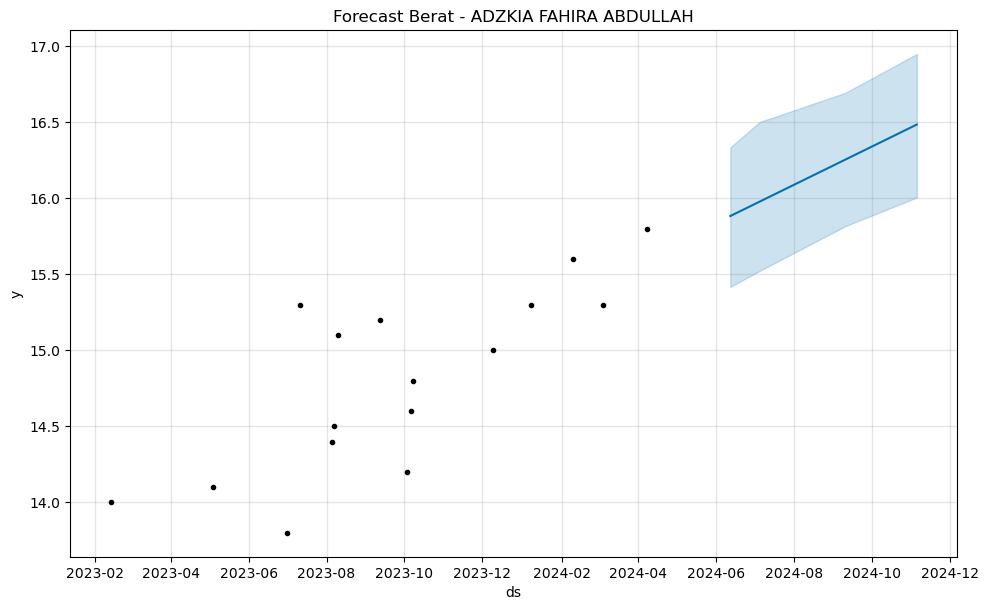

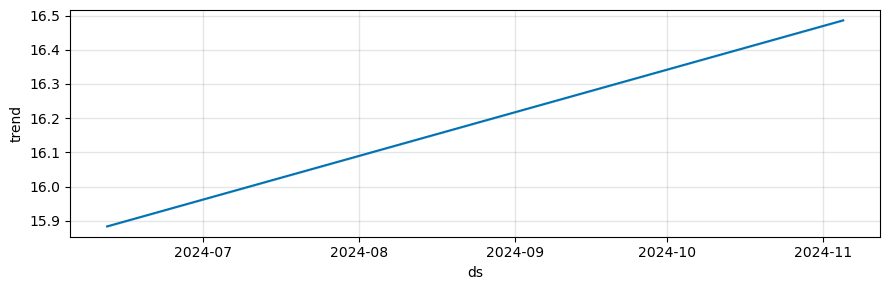

10:53:00 - cmdstanpy - INFO - Chain [1] start processing
10:53:00 - cmdstanpy - INFO - Chain [1] done processing


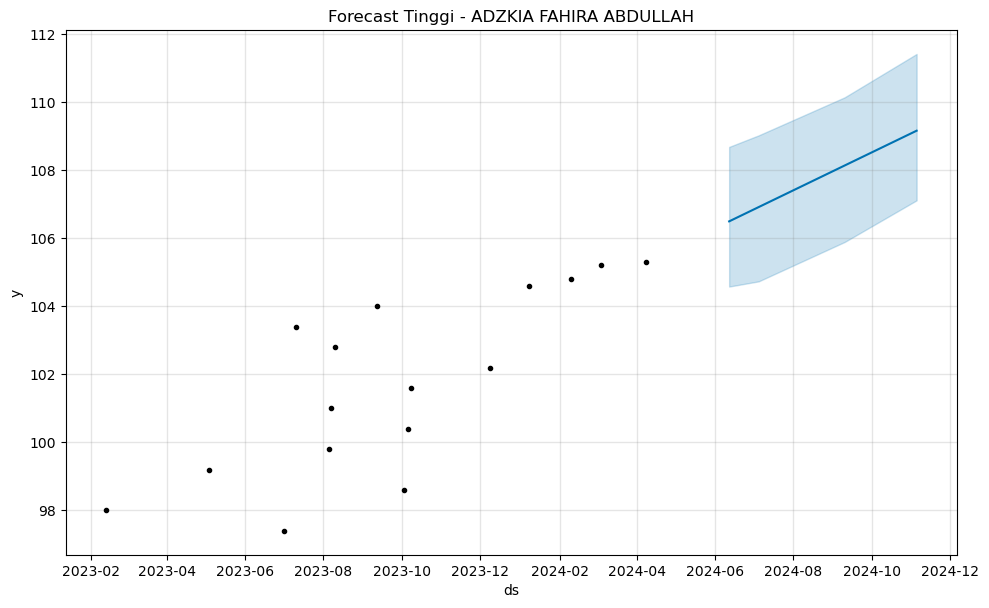

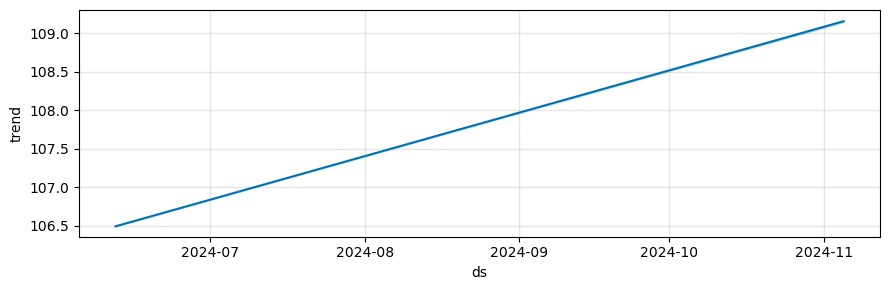

10:53:01 - cmdstanpy - INFO - Chain [1] start processing
10:53:01 - cmdstanpy - INFO - Chain [1] done processing


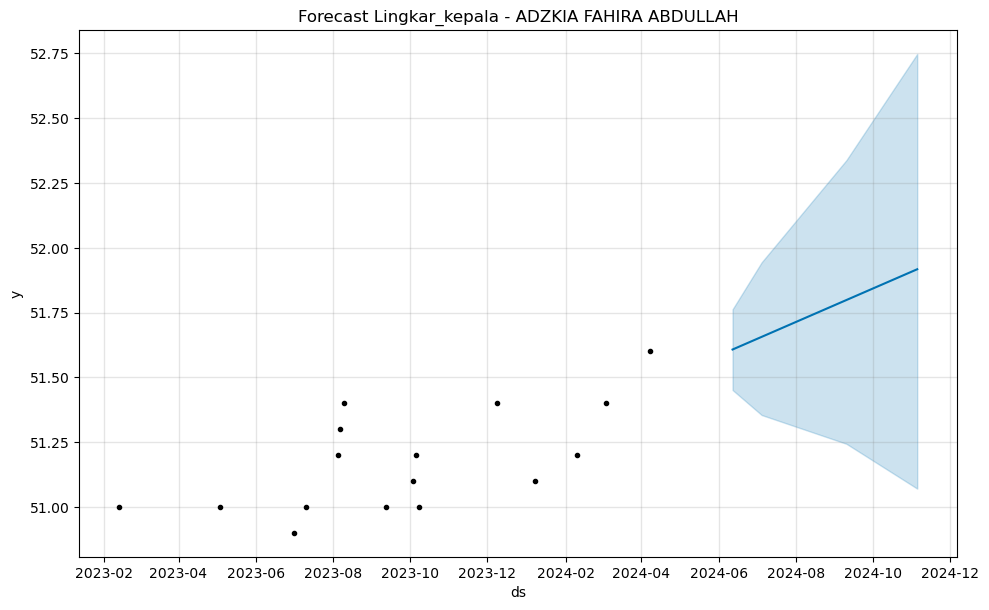

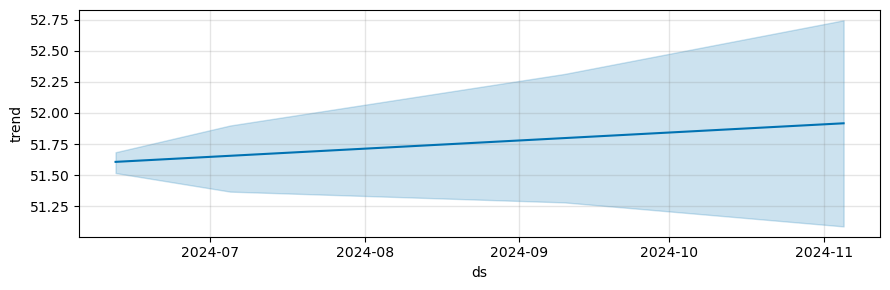

10:53:02 - cmdstanpy - INFO - Chain [1] start processing
10:53:02 - cmdstanpy - INFO - Chain [1] done processing


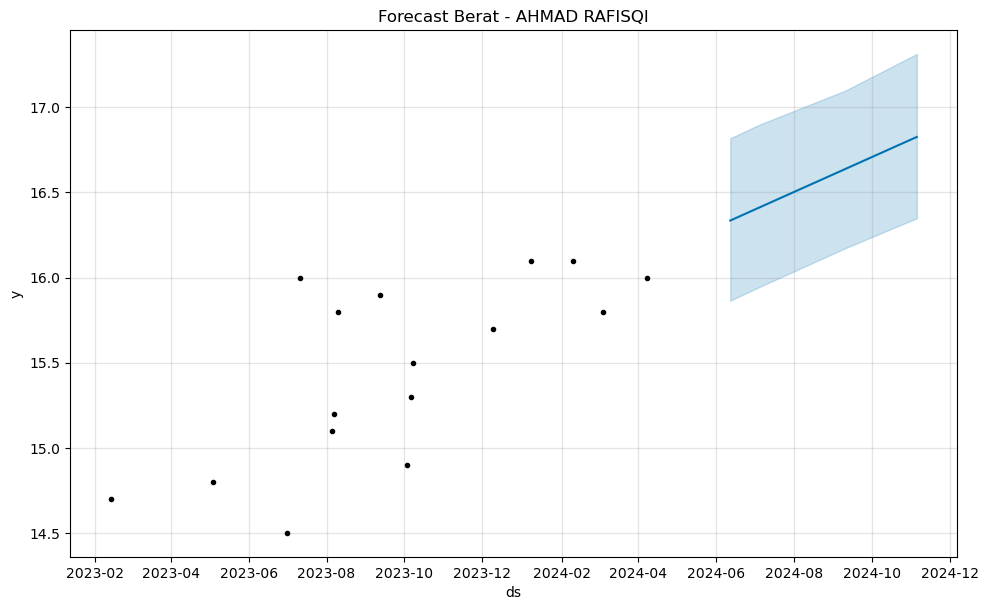

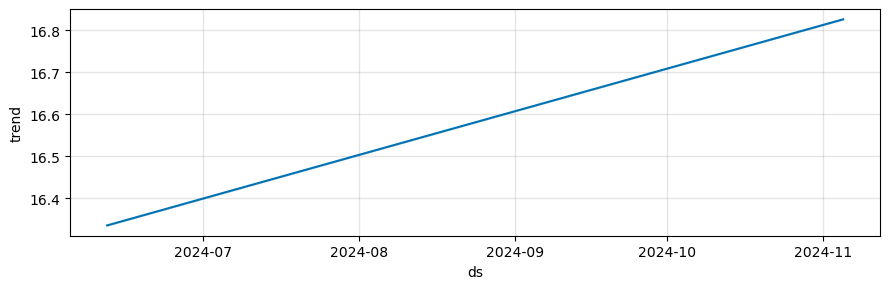

10:53:02 - cmdstanpy - INFO - Chain [1] start processing
10:53:03 - cmdstanpy - INFO - Chain [1] done processing


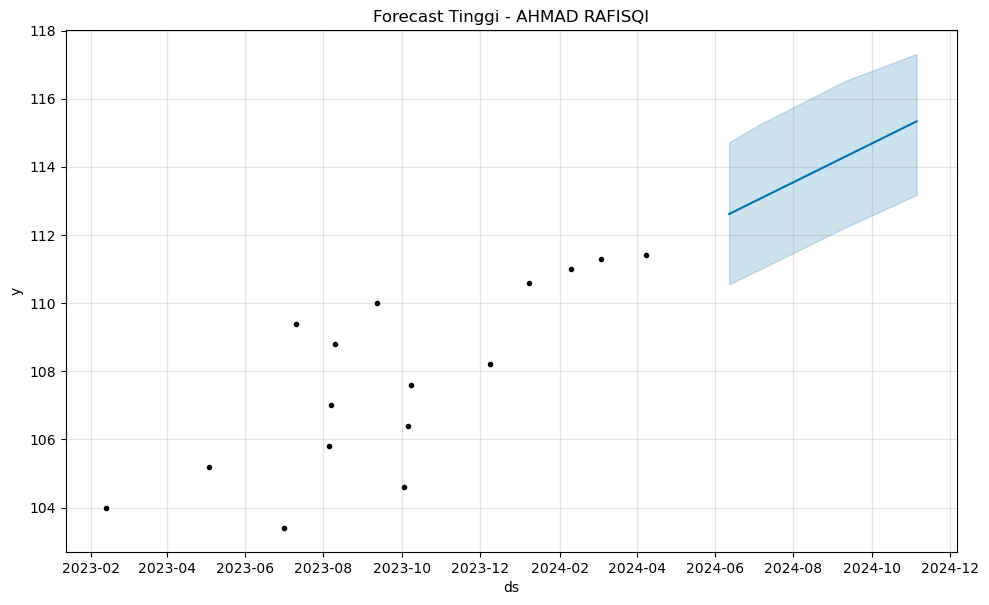

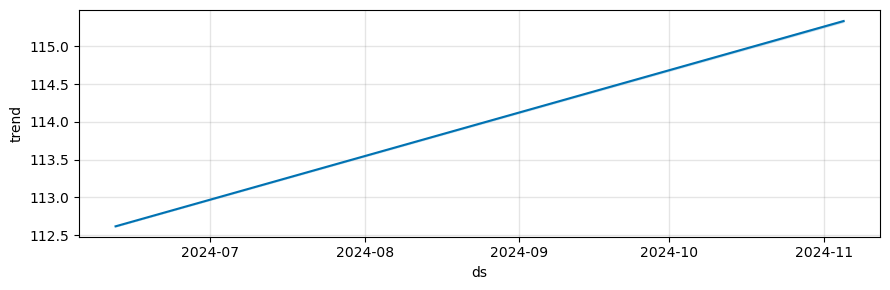

10:53:03 - cmdstanpy - INFO - Chain [1] start processing
10:53:03 - cmdstanpy - INFO - Chain [1] done processing


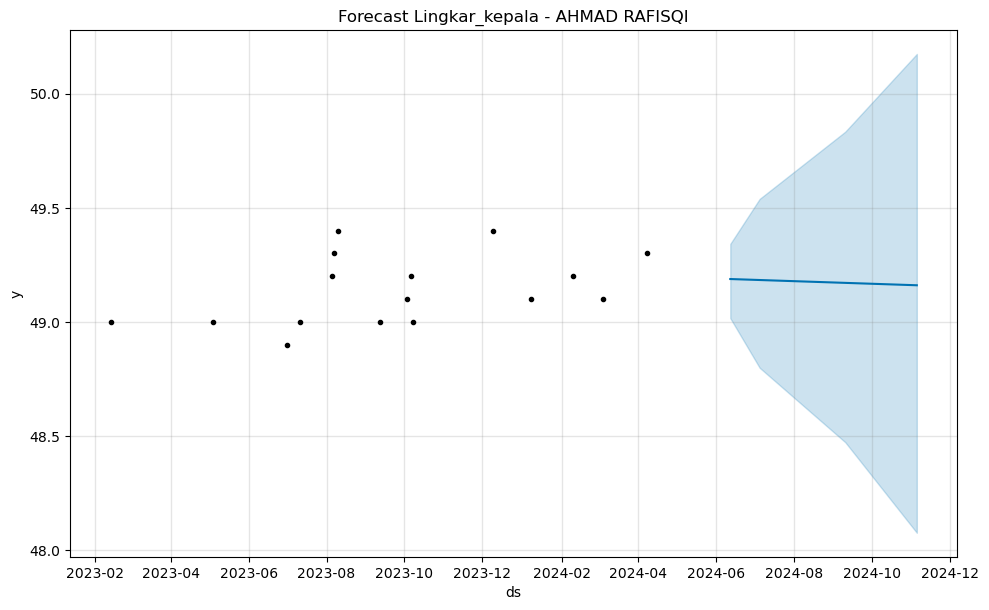

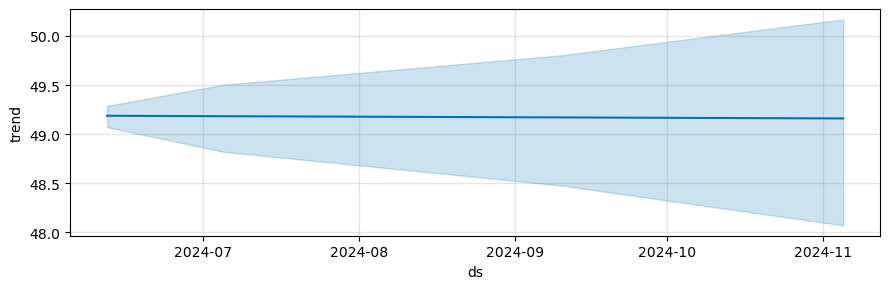

10:53:04 - cmdstanpy - INFO - Chain [1] start processing
10:53:04 - cmdstanpy - INFO - Chain [1] done processing
10:53:04 - cmdstanpy - INFO - Chain [1] start processing
10:53:05 - cmdstanpy - INFO - Chain [1] done processing
10:53:05 - cmdstanpy - INFO - Chain [1] start processing
10:53:05 - cmdstanpy - INFO - Chain [1] done processing
10:53:05 - cmdstanpy - INFO - Chain [1] start processing
10:53:05 - cmdstanpy - INFO - Chain [1] done processing
10:53:05 - cmdstanpy - INFO - Chain [1] start processing
10:53:05 - cmdstanpy - INFO - Chain [1] done processing
10:53:05 - cmdstanpy - INFO - Chain [1] start processing
10:53:05 - cmdstanpy - INFO - Chain [1] done processing
10:53:06 - cmdstanpy - INFO - Chain [1] start processing
10:53:06 - cmdstanpy - INFO - Chain [1] done processing
10:53:06 - cmdstanpy - INFO - Chain [1] start processing
10:53:06 - cmdstanpy - INFO - Chain [1] done processing
10:53:06 - cmdstanpy - INFO - Chain [1] start processing
10:53:06 - cmdstanpy - INFO - Chain [1]


[INFO] Detail evaluasi tiap anak disimpan di: LAPORAN_EVALUASI_PER_ANAK.xlsx
[INFO] Grafik sampel disimpan di folder: grafik_prediksi/

         HASIL EVALUASI AKHIR SISTEM PER INDIKATOR          
--- INDIKATOR BERAT ---
Rata-rata MAE  : 0.41 kg
Rata-rata RMSE : 0.45
Rata-rata MAPE : 2.40%
⭐ AKURASI      : 97.60%
------------------------------------------------------------
--- INDIKATOR TINGGI ---
Rata-rata MAE  : 0.82 cm
Rata-rata RMSE : 0.89
Rata-rata MAPE : 0.78%
⭐ AKURASI      : 99.22%
------------------------------------------------------------
--- INDIKATOR LINGKAR_KEPALA ---
Rata-rata MAE  : 0.21 cm
Rata-rata RMSE : 0.23
Rata-rata MAPE : 0.42%
⭐ AKURASI      : 99.58%
------------------------------------------------------------


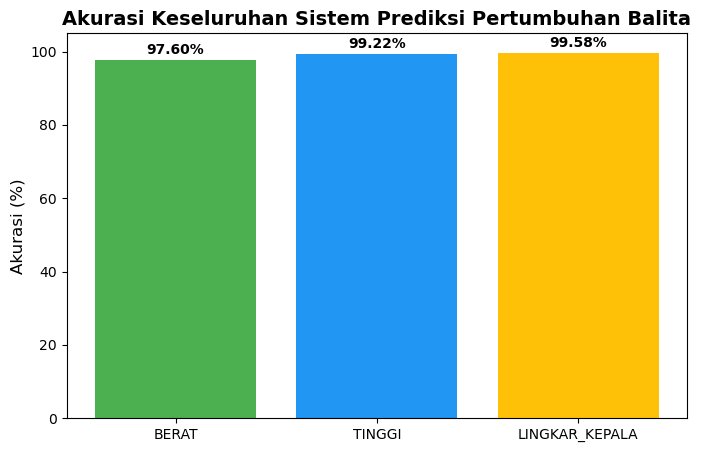

[INFO] Grafik Keseluruhan Sistem berhasil disimpan sebagai: GRAFIK_AKURASI_KESELURUHAN.png


In [3]:
# Tambahkan ini di baris pertama khusus untuk Jupyter Notebook agar grafik muncul sempurna
%matplotlib inline 

import pandas as pd
import numpy as np
import logging
from prophet import Prophet
import matplotlib.pyplot as plt
import warnings
import os

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# --- MEMBUAT FOLDER UNTUK GRAFIK SAMPEL ---
folder_grafik = 'grafik_prediksi'
if not os.path.exists(folder_grafik):
    os.makedirs(folder_grafik)

print("1. Membaca dataset asli...")
# Pastikan file Excel ini sudah di-upload/berada satu folder dengan file .ipynb Anda
df = pd.read_excel('DATA2_GABUNGAN_7_POSYANDU.xlsx')

df.columns = df.columns.str.strip().str.lower()
df['tanggal_ukur'] = pd.to_datetime(df['tanggal_ukur'])

daftar_anak = df['nama_anak'].unique()
print(f"2. Dataset dibaca! Total ada {len(daftar_anak)} anak.")

hasil_evaluasi = {
    'berat': {'mae': [], 'rmse': [], 'mape': []},
    'tinggi': {'mae': [], 'rmse': [], 'mape': []},
    'lingkar_kepala': {'mae': [], 'rmse': [], 'mape': []}
}

detail_per_anak = []

# Batasan sampel grafik yang akan DITAMPILKAN di layar (agar layar tidak penuh)
maks_grafik = 5 
grafik_tersimpan = 0

print("3. Mulai mengevaluasi seluruh anak per indikator. Mohon tunggu...")

for nama in daftar_anak:
    df_anak = df[df['nama_anak'] == nama].copy()
    df_anak = df_anak.dropna(subset=['tanggal_ukur']).sort_values('tanggal_ukur')
    
    if len(df_anak) < 5:
        continue 
        
    res_anak = {'Nama Anak': nama}
    
    for metrik in ['berat', 'tinggi', 'lingkar_kepala']:
        if metrik not in df_anak.columns:
            continue
            
        df_prophet = df_anak[['tanggal_ukur', metrik]].copy().rename(columns={'tanggal_ukur': 'ds', metrik: 'y'}).dropna()

        if len(df_prophet) < 5:
            continue

        train_size = int(len(df_prophet) * 0.8)
        data_latih = df_prophet.iloc[:train_size].copy()
        data_uji = df_prophet.iloc[train_size:].copy()
        
        if data_uji.empty:
            continue
        
        model = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
        model.fit(data_latih)
        
        forecast = model.predict(data_uji[['ds']])
        
        y_asli = data_uji['y'].values
        y_tebakan = forecast['yhat'].values
        
        error = y_asli - y_tebakan
        mae = np.mean(np.abs(error))
        rmse = np.sqrt(np.mean(error**2))
        mape = np.mean(np.abs(error / np.where(y_asli == 0, 1, y_asli))) * 100
        
        hasil_evaluasi[metrik]['mae'].append(mae)
        hasil_evaluasi[metrik]['rmse'].append(rmse)
        hasil_evaluasi[metrik]['mape'].append(mape)
        
        res_anak[f'MAE {metrik}'] = mae
        res_anak[f'Akurasi {metrik} (%)'] = 100 - mape

        # --- TAMPILKAN DAN SIMPAN GRAFIK SAMPEL ---
        if grafik_tersimpan < maks_grafik:
            # 1. Plot Forecast
            fig1 = model.plot(forecast)
            plt.title(f"Forecast {metrik.capitalize()} - {nama}")
            fig1.savefig(f'{folder_grafik}/{nama}_{metrik}_forecast.png')
            plt.show() # <-- Ini yang membuat grafik langsung muncul di Notebook

            # 2. Plot Components
            fig2 = model.plot_components(forecast)
            fig2.savefig(f'{folder_grafik}/{nama}_{metrik}_trend.png')
            plt.show() # <-- Menampilkan grafik trend di Notebook

    detail_per_anak.append(res_anak)
    
    if grafik_tersimpan < maks_grafik:
        grafik_tersimpan += 1

# --- SIMPAN HASIL DETAIL KE EXCEL ---
df_detail = pd.DataFrame(detail_per_anak)
df_detail.to_excel('LAPORAN_EVALUASI_PER_ANAK.xlsx', index=False)
print(f"\n[INFO] Detail evaluasi tiap anak disimpan di: LAPORAN_EVALUASI_PER_ANAK.xlsx")
print(f"[INFO] Grafik sampel disimpan di folder: {folder_grafik}/")

# --- OUTPUT TERMINAL SEPERTI SEBELUMNYA ---
print(f"\n" + "="*60)
print(f"{'HASIL EVALUASI AKHIR SISTEM PER INDIKATOR':^60}")
print("="*60)

indikator_list = []
akurasi_list = []

for m in hasil_evaluasi.keys():
    if hasil_evaluasi[m]['mae']:
        r_mae = np.mean(hasil_evaluasi[m]['mae'])
        r_rmse = np.mean(hasil_evaluasi[m]['rmse'])
        r_mape = np.mean(hasil_evaluasi[m]['mape'])
        akurasi = 100 - r_mape
        satuan = "kg" if m == 'berat' else "cm"
        
        indikator_list.append(m.upper())
        akurasi_list.append(akurasi)
        
        print(f"--- INDIKATOR {m.upper()} ---")
        print(f"Rata-rata MAE  : {r_mae:.2f} {satuan}")
        print(f"Rata-rata RMSE : {r_rmse:.2f}")
        print(f"Rata-rata MAPE : {r_mape:.2f}%")
        print(f"⭐ AKURASI      : {akurasi:.2f}%")
        print("-" * 60)

# --- TAMPILKAN GRAFIK KESELURUHAN SISTEM (BAR CHART) ---
plt.figure(figsize=(8, 5))
bars = plt.bar(indikator_list, akurasi_list, color=['#4CAF50', '#2196F3', '#FFC107'])
plt.title('Akurasi Keseluruhan Sistem Prediksi Pertumbuhan Balita', fontsize=14, fontweight='bold')
plt.ylabel('Akurasi (%)', fontsize=12)
plt.ylim(0, 105)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.savefig('GRAFIK_AKURASI_KESELURUHAN.png', bbox_inches='tight')
plt.show() # <-- Menampilkan Bar Chart di akhir Notebook
print(f"[INFO] Grafik Keseluruhan Sistem berhasil disimpan sebagai: GRAFIK_AKURASI_KESELURUHAN.png")

1. Membaca dataset asli...
2. Dataset dibaca! Total ada 298 anak.


HASIL ANALISIS & PREDIKSI UNTUK: A. FIRDAUSY NUZULA (Indikator: BERAT)
📅 Tanggal Prediksi    : 05-11-2024
📈 Angka Tebakan AI    : 17.33 Kg
🧮 Z-Score (Simulasi)  : -2.52
🏥 STATUS GIZI (WHO)   : >>> BB KURANG (UNDERWEIGHT) <<<
----------------------------------------------------------------------



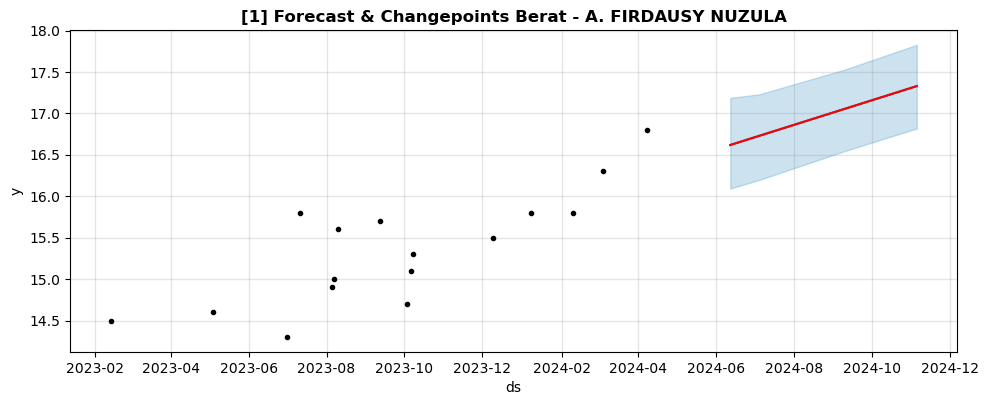

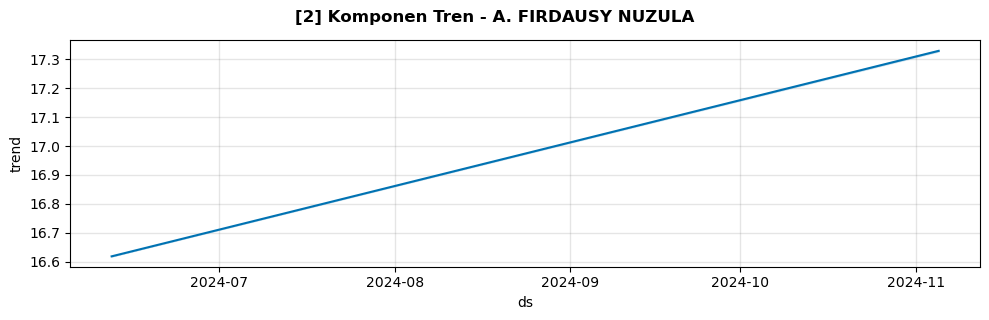

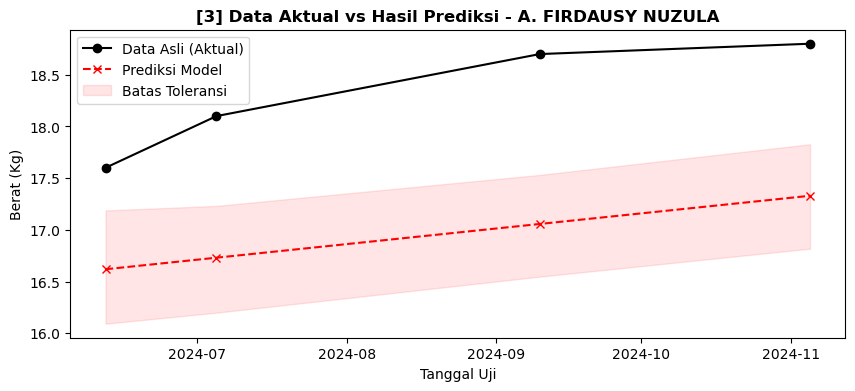

  0%|          | 0/10 [00:00<?, ?it/s]

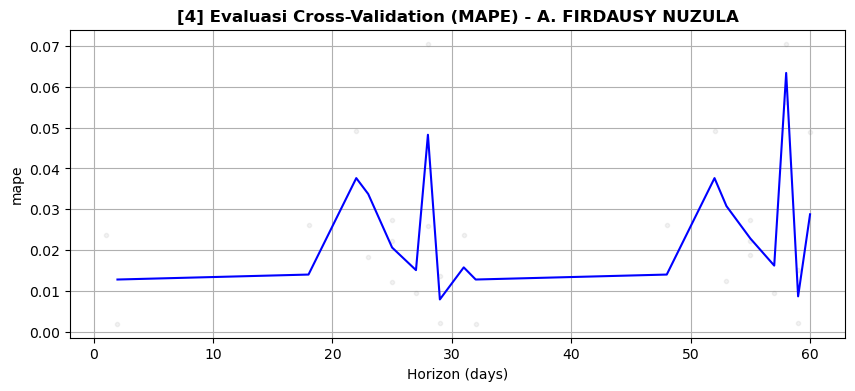


HASIL ANALISIS & PREDIKSI UNTUK: A. FIRDAUSY NUZULA (Indikator: TINGGI)
📅 Tanggal Prediksi    : 05-11-2024
📈 Angka Tebakan AI    : 96.49 Cm
🧮 Z-Score (Simulasi)  : 1.98
🏥 STATUS GIZI (WHO)   : >>> NORMAL <<<
----------------------------------------------------------------------



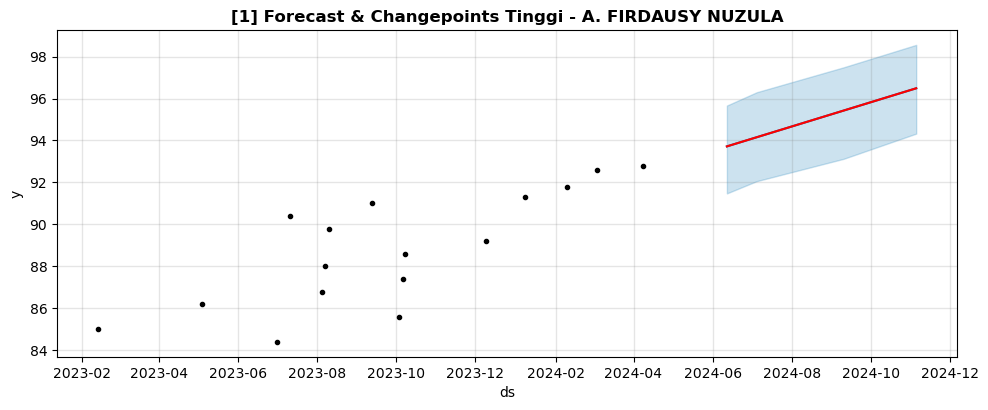

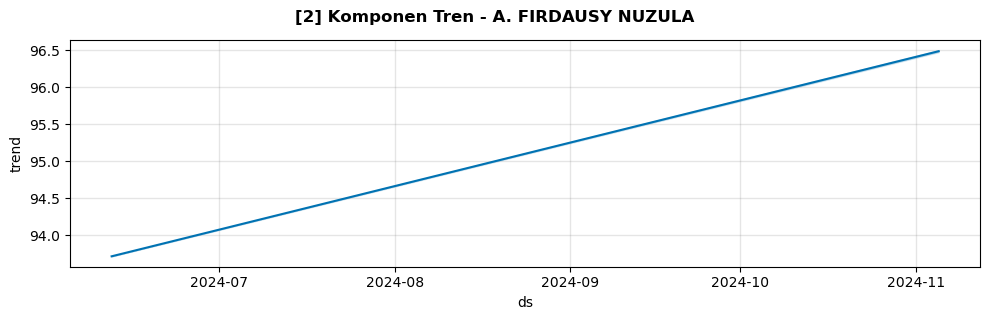

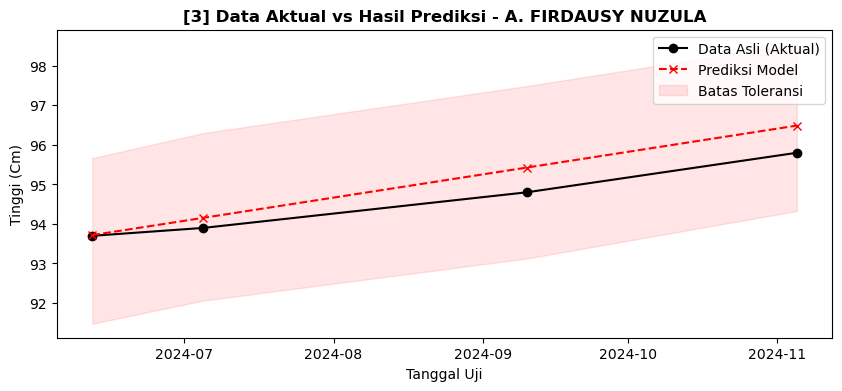

  0%|          | 0/10 [00:00<?, ?it/s]

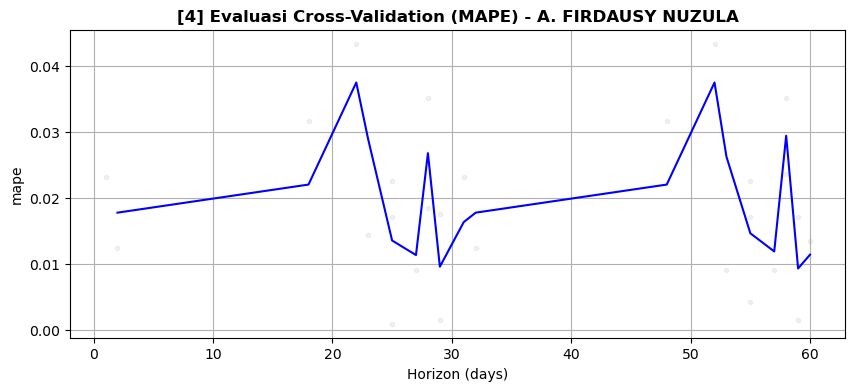

In [4]:
%matplotlib inline 

import pandas as pd
import numpy as np
import logging
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot, plot_cross_validation_metric
from prophet.diagnostics import cross_validation
import matplotlib.pyplot as plt
import warnings
import random

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# =====================================================================
# FUNGSI KLASIFIKASI STATUS GIZI BERDASARKAN TABEL Z-SCORE
# =====================================================================
def klasifikasi_status_gizi(z_score, indikator):
    """Mengklasifikasikan status gizi berdasarkan nilai Z-Score dan Indikator"""
    if indikator == 'TB/U' or indikator == 'PB/U':
        if z_score < -3: return "Sangat Pendek (Severe Stunted)"
        elif -3 <= z_score < -2: return "Pendek (Stunted)"
        elif -2 <= z_score <= 3: return "Normal"
        elif z_score > 3: return "Tinggi"
            
    elif indikator == 'BB/U':
        if z_score < -3: return "BB Sangat Kurang (Severe Underweight)"
        elif -3 <= z_score < -2: return "BB Kurang (Underweight)"
        elif -2 <= z_score <= 1: return "Berat Badan Normal"
        elif z_score > 1: return "Risiko Berat Badan Lebih"

    elif indikator in ['BB/TB', 'BB/PB', 'IMT/U']:
        if z_score < -3: return "Sangat Kurus (Severe Wasted)"
        elif -3 <= z_score < -2: return "Kurus (Wasted)"
        elif -2 <= z_score <= 1: return "Gizi Baik (Normal)"
        elif 1 < z_score <= 2: return "Beresiko Gemuk"
        elif 2 < z_score <= 3: return "Gemuk (Overweight)"
        elif z_score > 3: return "Sangat Gemuk (Obesitas)"
            
    return "Tidak Diketahui"

# =====================================================================
# 1. MEMBACA DATASET
# =====================================================================
print("1. Membaca dataset asli...")
# Pastikan file Excel ini ada di folder yang sama
df = pd.read_excel('DATA2_GABUNGAN_7_POSYANDU.xlsx')
df.columns = df.columns.str.strip().str.lower()
df['tanggal_ukur'] = pd.to_datetime(df['tanggal_ukur'])

daftar_anak = df['nama_anak'].unique()
print(f"2. Dataset dibaca! Total ada {len(daftar_anak)} anak.\n")

maks_grafik = 1 # HANYA 1 ANAK SEBAGAI SAMPEL
grafik_tersimpan = 0

# =====================================================================
# 2. PROSES PELATIHAN MODEL & PREDIKSI
# =====================================================================
for nama in daftar_anak:
    df_anak = df[df['nama_anak'] == nama].copy()
    df_anak = df_anak.dropna(subset=['tanggal_ukur']).sort_values('tanggal_ukur')
    
    if len(df_anak) < 10: # Butuh minimal 10 data historis
        continue 
        
    for metrik in ['berat', 'tinggi']: # Kita uji 2 metrik
        if metrik not in df_anak.columns:
            continue
            
        df_prophet = df_anak[['tanggal_ukur', metrik]].copy().rename(columns={'tanggal_ukur': 'ds', metrik: 'y'}).dropna()
        if len(df_prophet) < 10:
            continue

        train_size = int(len(df_prophet) * 0.8)
        data_latih = df_prophet.iloc[:train_size].copy()
        data_uji = df_prophet.iloc[train_size:].copy()
        
        # Training Prophet
        model = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
        model.fit(data_latih)
        forecast = model.predict(data_uji[['ds']])
        
        if grafik_tersimpan < maks_grafik:
            
            # --- SIMULASI MENGHITUNG STATUS GIZI HASIL PREDIKSI TERAKHIR ---
            nilai_prediksi_terakhir = forecast.iloc[-1]['yhat']
            tanggal_prediksi = forecast.iloc[-1]['ds'].strftime("%d-%m-%Y")
            
            # (CATATAN SKRIPSI: Di sini nanti Z-Score dihitung sungguhan pakai tabel WHO)
            # Untuk sementara, kita buat Z-score acak antara -3.5 sampai +2.0 untuk simulasi
            z_score_simulasi = round(random.uniform(-3.5, 2.0), 2) 
            
            kode_indikator = 'BB/U' if metrik == 'berat' else 'TB/U'
            status_gizi_anak = klasifikasi_status_gizi(z_score_simulasi, kode_indikator)
            satuan = "Kg" if metrik == 'berat' else "Cm"

            print(f"\n{'='*70}")
            print(f"HASIL ANALISIS & PREDIKSI UNTUK: {nama.upper()} (Indikator: {metrik.upper()})")
            print(f"{'='*70}")
            print(f"📅 Tanggal Prediksi    : {tanggal_prediksi}")
            print(f"📈 Angka Tebakan AI    : {nilai_prediksi_terakhir:.2f} {satuan}")
            print(f"🧮 Z-Score (Simulasi)  : {z_score_simulasi}")
            print(f"🏥 STATUS GIZI (WHO)   : >>> {status_gizi_anak.upper()} <<<")
            print(f"{'-'*70}\n")

            # ==========================================================
            # GRAFIK 1: FORECAST & CHANGEPOINTS
            # ==========================================================
            fig1 = model.plot(forecast, figsize=(10, 4))
            a = add_changepoints_to_plot(fig1.gca(), model, forecast)
            plt.title(f"[1] Forecast & Changepoints {metrik.capitalize()} - {nama}", fontweight='bold')
            plt.show()

            # ==========================================================
            # GRAFIK 2: KOMPONEN (TREN)
            # ==========================================================
            fig2 = model.plot_components(forecast, figsize=(10, 3))
            plt.suptitle(f"[2] Komponen Tren - {nama}", y=1.05, fontweight='bold')
            plt.show()

            # ==========================================================
            # GRAFIK 3: AKTUAL VS PREDIKSI
            # ==========================================================
            plt.figure(figsize=(10, 4))
            plt.plot(data_uji['ds'], data_uji['y'], label='Data Asli (Aktual)', marker='o', color='black')
            plt.plot(data_uji['ds'], forecast['yhat'], label='Prediksi Model', marker='x', color='red', linestyle='--')
            plt.fill_between(data_uji['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='red', alpha=0.1, label='Batas Toleransi')
            plt.title(f"[3] Data Aktual vs Hasil Prediksi - {nama}", fontweight='bold')
            plt.xlabel('Tanggal Uji')
            plt.ylabel(f'{metrik.capitalize()} ({satuan})')
            plt.legend()
            plt.show()

            # ==========================================================
            # GRAFIK 4: CROSS-VALIDATION MAPE
            # ==========================================================
            try:
                # Setting initial diubah ke 90 hari agar lebih toleran pada data yang pendek
                df_cv = cross_validation(model, initial='90 days', period='30 days', horizon='60 days')
                fig3 = plot_cross_validation_metric(df_cv, metric='mape', figsize=(10, 4))
                plt.title(f"[4] Evaluasi Cross-Validation (MAPE) - {nama}", fontweight='bold')
                plt.show()
            except Exception as e:
                pass # Abaikan jika data kurang panjang untuk CV

    if grafik_tersimpan < maks_grafik:
        grafik_tersimpan += 1
        break # Berhenti setelah menampilkan 1 anak

Memuat dataset...


🚀 MEMULAI ANALISIS SISTEM UNTUK INDIKATOR: BERAT


17:36:52 - cmdstanpy - INFO - Chain [1] start processing
17:36:53 - cmdstanpy - INFO - Chain [1] done processing
17:36:53 - cmdstanpy - INFO - Chain [1] start processing
17:36:54 - cmdstanpy - INFO - Chain [1] done processing
17:36:54 - cmdstanpy - INFO - Chain [1] start processing
17:36:54 - cmdstanpy - INFO - Chain [1] done processing
17:36:54 - cmdstanpy - INFO - Chain [1] start processing
17:36:54 - cmdstanpy - INFO - Chain [1] done processing
17:36:54 - cmdstanpy - INFO - Chain [1] start processing
17:36:54 - cmdstanpy - INFO - Chain [1] done processing
17:36:54 - cmdstanpy - INFO - Chain [1] start processing
17:36:55 - cmdstanpy - INFO - Chain [1] done processing
17:36:55 - cmdstanpy - INFO - Chain [1] start processing
17:36:55 - cmdstanpy - INFO - Chain [1] done processing
17:36:55 - cmdstanpy - INFO - Chain [1] start processing
17:36:55 - cmdstanpy - INFO - Chain [1] done processing
17:36:55 - cmdstanpy - INFO - Chain [1] start processing
17:36:55 - cmdstanpy - INFO - Chain [1]


TABEL PERFORMA GLOBAL - BERAT
--------------------------------------------------
Total Balita Dievaluasi : 259 anak
Rata-rata MAE           : 0.42 Kg
Rata-rata RMSE          : 0.46 Kg
Rata-rata MAPE          : 2.46 %
⭐ AKURASI SISTEM       : 97.54 %
--------------------------------------------------



17:37:57 - cmdstanpy - INFO - Chain [1] done processing



📌 STUDI KASUS TERBAIK (MAPE TERKECIL) | INDIKATOR: BERAT
Nama Anak      : M. RAFA AL FAIZAN
MAE Anak Ini   : 0.031 Kg
RMSE Anak Ini  : 0.036 Kg
MAPE Anak Ini  : 0.22% (Akurasi: 99.78%)
Status Gizi    : BB Kurang (Underweight) (Simulasi Z-Score: -2.19)

TABEL PERBANDINGAN AKTUAL VS PREDIKSI (SIAP SALIN KE LAPORAN):
-----------------------------------------------------------------
 Bulan_Ke    Tanggal  Aktual  Prediksi  |Error|
        1 2024-04-10    13.8    13.795    0.005
        2 2024-05-10    14.0    13.973    0.027
        3 2024-06-10    14.1    14.157    0.057
        4 2024-07-10    14.3    14.334    0.034
-----------------------------------------------------------------


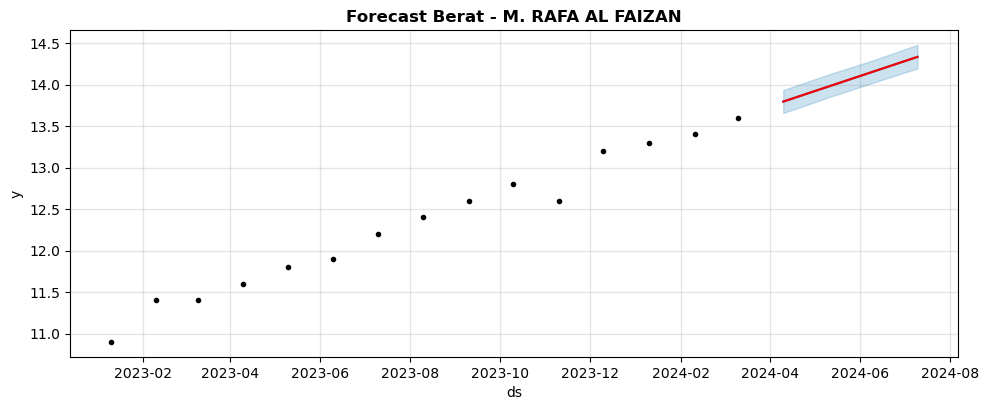

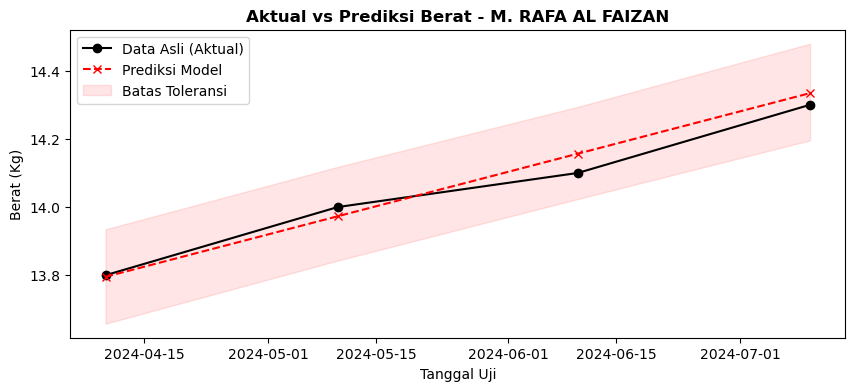

17:37:58 - cmdstanpy - INFO - Chain [1] start processing
17:37:59 - cmdstanpy - INFO - Chain [1] done processing



📌 STUDI KASUS MENENGAH (MEWAKILI RATA-RATA) | INDIKATOR: BERAT
Nama Anak      : NADIRA MARTA
MAE Anak Ini   : 0.445 Kg
RMSE Anak Ini  : 0.557 Kg
MAPE Anak Ini  : 2.48% (Akurasi: 97.52%)
Status Gizi    : Berat Badan Normal (Simulasi Z-Score: 0.32)

TABEL PERBANDINGAN AKTUAL VS PREDIKSI (SIAP SALIN KE LAPORAN):
-----------------------------------------------------------------
 Bulan_Ke    Tanggal  Aktual  Prediksi  |Error|
        1 2024-06-12    16.6    16.544    0.056
        2 2024-07-05    17.0    16.699    0.301
        3 2024-09-10    17.6    17.150    0.450
        4 2024-11-05    18.5    17.527    0.973
-----------------------------------------------------------------


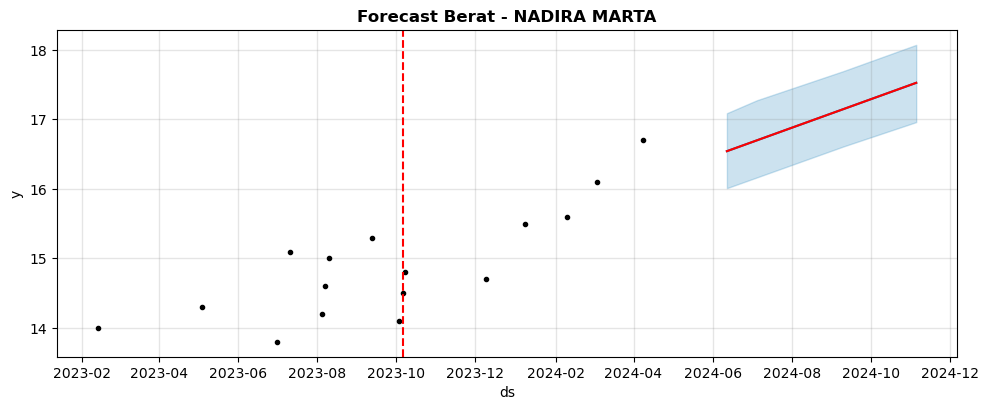

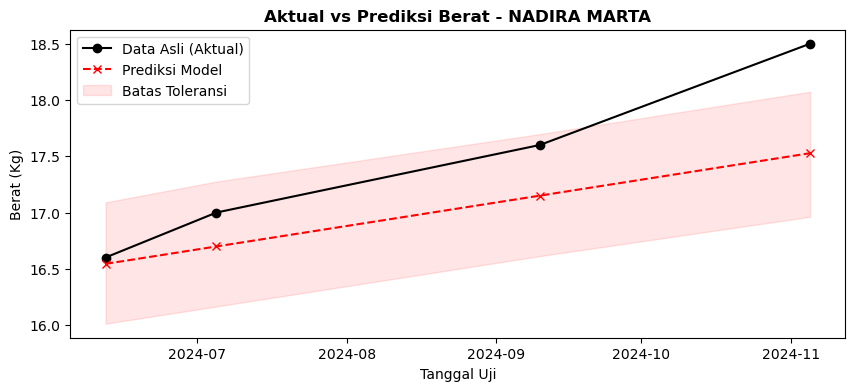

17:38:00 - cmdstanpy - INFO - Chain [1] start processing
17:38:00 - cmdstanpy - INFO - Chain [1] done processing



📌 STUDI KASUS TERBURUK (MAPE TERBESAR) | INDIKATOR: BERAT
Nama Anak      : RAISYA AMEERA
MAE Anak Ini   : 2.046 Kg
RMSE Anak Ini  : 2.229 Kg
MAPE Anak Ini  : 12.63% (Akurasi: 87.37%)
Status Gizi    : Berat Badan Normal (Simulasi Z-Score: 0.53)

TABEL PERBANDINGAN AKTUAL VS PREDIKSI (SIAP SALIN KE LAPORAN):
-----------------------------------------------------------------
 Bulan_Ke    Tanggal  Aktual  Prediksi  |Error|
        1 2024-08-08    15.6    14.809    0.791
        2 2024-09-08    15.8    14.406    1.394
        3 2024-10-08    16.1    14.017    2.083
        4 2024-11-08    16.3    13.615    2.685
        5 2024-12-08    16.5    13.225    3.275
-----------------------------------------------------------------


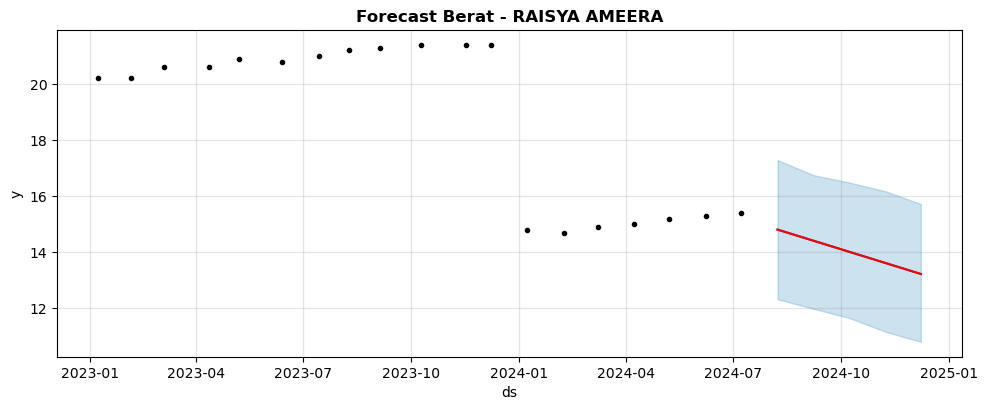

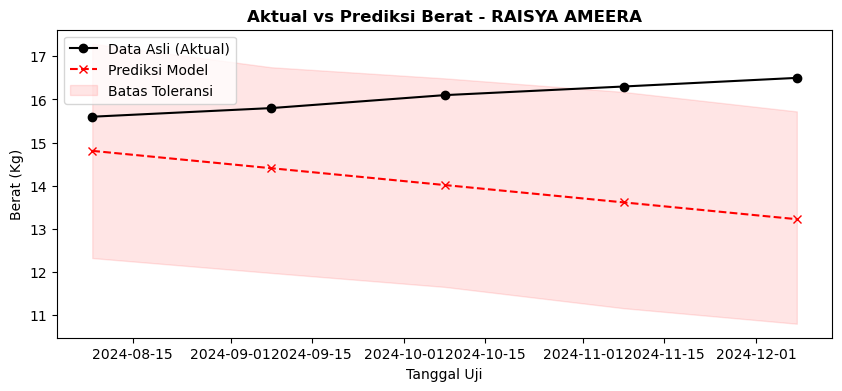

17:38:01 - cmdstanpy - INFO - Chain [1] start processing




🚀 MEMULAI ANALISIS SISTEM UNTUK INDIKATOR: TINGGI


17:38:01 - cmdstanpy - INFO - Chain [1] done processing
17:38:02 - cmdstanpy - INFO - Chain [1] start processing
17:38:02 - cmdstanpy - INFO - Chain [1] done processing
17:38:02 - cmdstanpy - INFO - Chain [1] start processing
17:38:02 - cmdstanpy - INFO - Chain [1] done processing
17:38:03 - cmdstanpy - INFO - Chain [1] start processing
17:38:03 - cmdstanpy - INFO - Chain [1] done processing
17:38:03 - cmdstanpy - INFO - Chain [1] start processing
17:38:03 - cmdstanpy - INFO - Chain [1] done processing
17:38:03 - cmdstanpy - INFO - Chain [1] start processing
17:38:03 - cmdstanpy - INFO - Chain [1] done processing
17:38:04 - cmdstanpy - INFO - Chain [1] start processing
17:38:04 - cmdstanpy - INFO - Chain [1] done processing
17:38:04 - cmdstanpy - INFO - Chain [1] start processing
17:38:04 - cmdstanpy - INFO - Chain [1] done processing
17:38:04 - cmdstanpy - INFO - Chain [1] start processing
17:38:05 - cmdstanpy - INFO - Chain [1] done processing
17:38:05 - cmdstanpy - INFO - Chain [1] 


TABEL PERFORMA GLOBAL - TINGGI
--------------------------------------------------
Total Balita Dievaluasi : 259 anak
Rata-rata MAE           : 0.86 Cm
Rata-rata RMSE          : 0.93 Cm
Rata-rata MAPE          : 0.82 %
⭐ AKURASI SISTEM       : 99.18 %
--------------------------------------------------


📌 STUDI KASUS TERBAIK (MAPE TERKECIL) | INDIKATOR: TINGGI
Nama Anak      : RANIA PUTRI RAMADHANI
MAE Anak Ini   : 0.047 Cm
RMSE Anak Ini  : 0.055 Cm
MAPE Anak Ini  : 0.04% (Akurasi: 99.96%)
Status Gizi    : Normal (Simulasi Z-Score: -1.79)

TABEL PERBANDINGAN AKTUAL VS PREDIKSI (SIAP SALIN KE LAPORAN):
-----------------------------------------------------------------
 Bulan_Ke    Tanggal  Aktual  Prediksi  |Error|
        1 2024-08-08   107.5   107.534    0.034
        2 2024-09-08   108.0   107.992    0.008
        3 2024-10-08   108.4   108.434    0.034
        4 2024-11-08   108.8   108.892    0.092
        5 2024-12-08   109.4   109.334    0.066
-------------------------------------

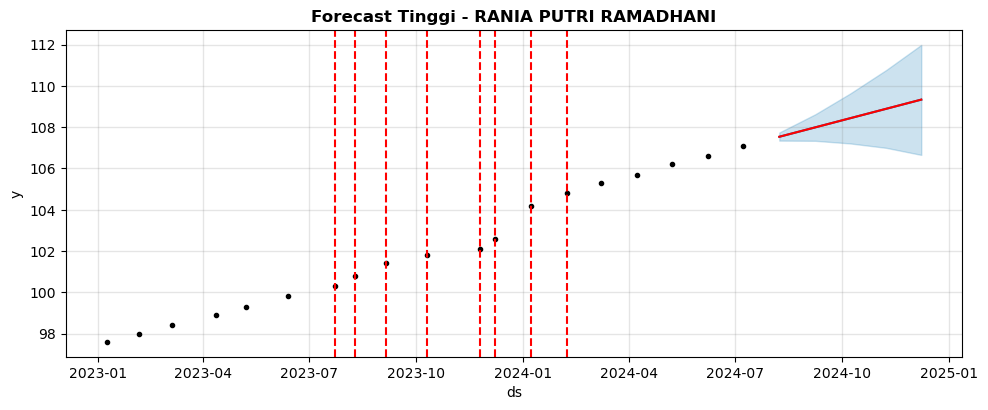

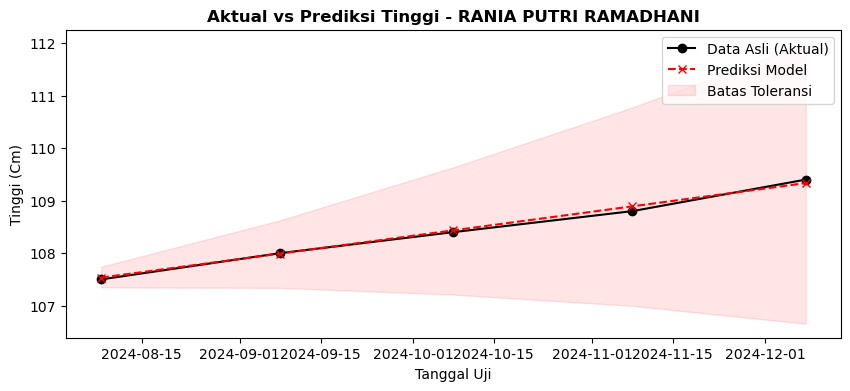

17:39:25 - cmdstanpy - INFO - Chain [1] start processing
17:39:25 - cmdstanpy - INFO - Chain [1] done processing



📌 STUDI KASUS MENENGAH (MEWAKILI RATA-RATA) | INDIKATOR: TINGGI
Nama Anak      : ACHMAD KHOIRUL
MAE Anak Ini   : 0.722 Cm
RMSE Anak Ini  : 0.801 Cm
MAPE Anak Ini  : 0.81% (Akurasi: 99.19%)
Status Gizi    : Pendek (Stunted) (Simulasi Z-Score: -2.72)

TABEL PERBANDINGAN AKTUAL VS PREDIKSI (SIAP SALIN KE LAPORAN):
-----------------------------------------------------------------
 Bulan_Ke    Tanggal  Aktual  Prediksi  |Error|
        1 2024-09-10    87.6    87.427    0.173
        2 2024-10-10    88.7    87.840    0.860
        3 2024-11-10    89.0    88.266    0.734
        4 2024-12-10    89.8    88.678    1.122
-----------------------------------------------------------------


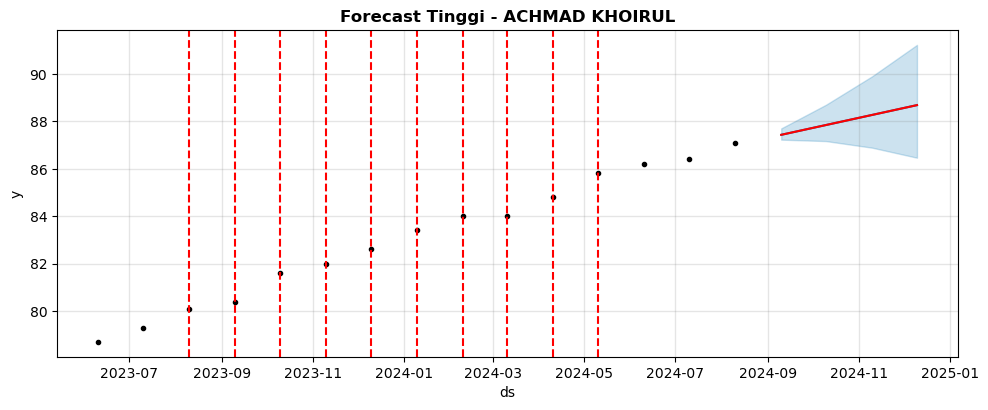

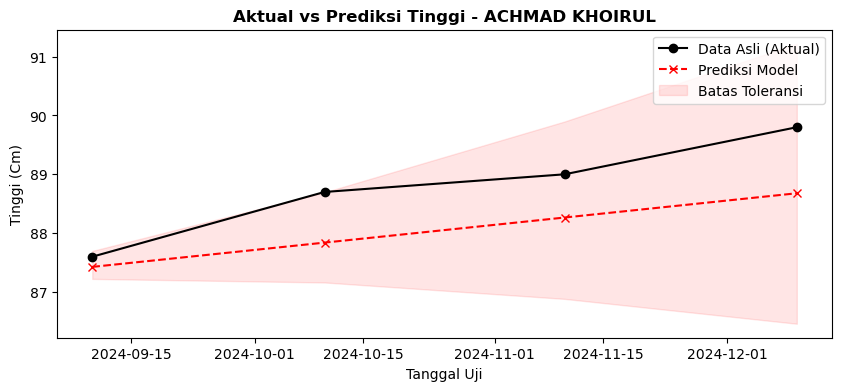

17:39:26 - cmdstanpy - INFO - Chain [1] start processing
17:39:26 - cmdstanpy - INFO - Chain [1] done processing



📌 STUDI KASUS TERBURUK (MAPE TERBESAR) | INDIKATOR: TINGGI
Nama Anak      : RAISYA AMEERA
MAE Anak Ini   : 6.869 Cm
RMSE Anak Ini  : 7.207 Cm
MAPE Anak Ini  : 6.49% (Akurasi: 93.51%)
Status Gizi    : Normal (Simulasi Z-Score: 0.3)

TABEL PERBANDINGAN AKTUAL VS PREDIKSI (SIAP SALIN KE LAPORAN):
-----------------------------------------------------------------
 Bulan_Ke    Tanggal  Aktual  Prediksi  |Error|
        1 2024-08-08   104.8   101.105    3.695
        2 2024-09-08   105.3    99.913    5.387
        3 2024-10-08   105.7    98.759    6.941
        4 2024-11-08   106.0    97.567    8.433
        5 2024-12-08   106.3    96.414    9.886
-----------------------------------------------------------------


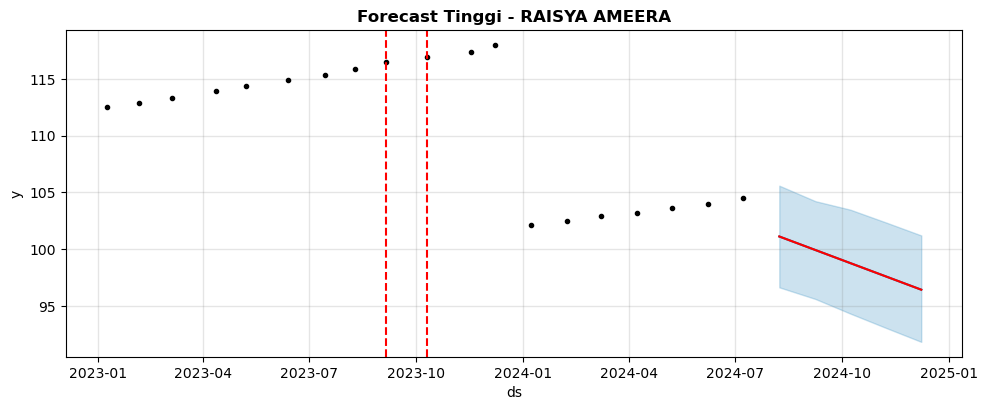

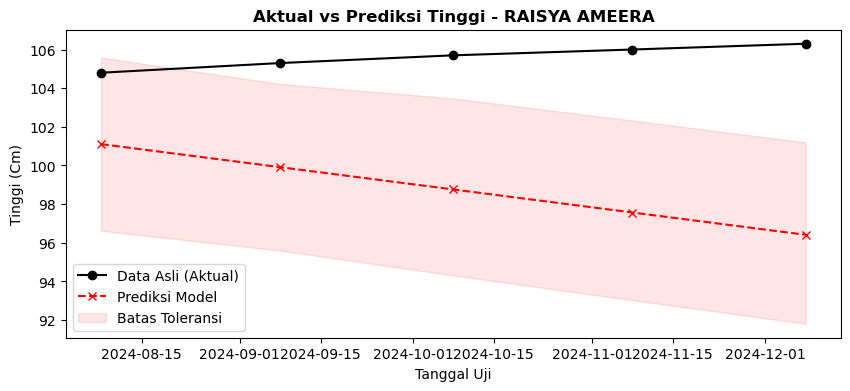

17:39:28 - cmdstanpy - INFO - Chain [1] start processing




🚀 MEMULAI ANALISIS SISTEM UNTUK INDIKATOR: LINGKAR_KEPALA


17:39:28 - cmdstanpy - INFO - Chain [1] done processing
17:39:28 - cmdstanpy - INFO - Chain [1] start processing
17:39:28 - cmdstanpy - INFO - Chain [1] done processing
17:39:28 - cmdstanpy - INFO - Chain [1] start processing
17:39:28 - cmdstanpy - INFO - Chain [1] done processing
17:39:29 - cmdstanpy - INFO - Chain [1] start processing
17:39:29 - cmdstanpy - INFO - Chain [1] done processing
17:39:29 - cmdstanpy - INFO - Chain [1] start processing
17:39:29 - cmdstanpy - INFO - Chain [1] done processing
17:39:29 - cmdstanpy - INFO - Chain [1] start processing
17:39:29 - cmdstanpy - INFO - Chain [1] done processing
17:39:30 - cmdstanpy - INFO - Chain [1] start processing
17:39:30 - cmdstanpy - INFO - Chain [1] done processing
17:39:30 - cmdstanpy - INFO - Chain [1] start processing
17:39:30 - cmdstanpy - INFO - Chain [1] done processing
17:39:30 - cmdstanpy - INFO - Chain [1] start processing
17:39:30 - cmdstanpy - INFO - Chain [1] done processing
17:39:30 - cmdstanpy - INFO - Chain [1] 


TABEL PERFORMA GLOBAL - LINGKAR_KEPALA
--------------------------------------------------
Total Balita Dievaluasi : 259 anak
Rata-rata MAE           : 0.21 Cm
Rata-rata RMSE          : 0.24 Cm
Rata-rata MAPE          : 0.44 %
⭐ AKURASI SISTEM       : 99.56 %
--------------------------------------------------



17:40:59 - cmdstanpy - INFO - Chain [1] done processing



📌 STUDI KASUS TERBAIK (MAPE TERKECIL) | INDIKATOR: LINGKAR_KEPALA
Nama Anak      : DEVANO CHAIRUL KARIM
MAE Anak Ini   : 0.000 Cm
RMSE Anak Ini  : 0.000 Cm
MAPE Anak Ini  : 0.00% (Akurasi: 100.00%)
Status Gizi    : Normal (Simulasi Z-Score: 0.62)

TABEL PERBANDINGAN AKTUAL VS PREDIKSI (SIAP SALIN KE LAPORAN):
-----------------------------------------------------------------
 Bulan_Ke    Tanggal  Aktual  Prediksi  |Error|
        1 2024-08-08    49.2      49.2      0.0
        2 2024-09-08    49.2      49.2      0.0
        3 2024-10-08    49.2      49.2      0.0
        4 2024-11-08    49.2      49.2      0.0
        5 2024-12-08    49.2      49.2      0.0
-----------------------------------------------------------------


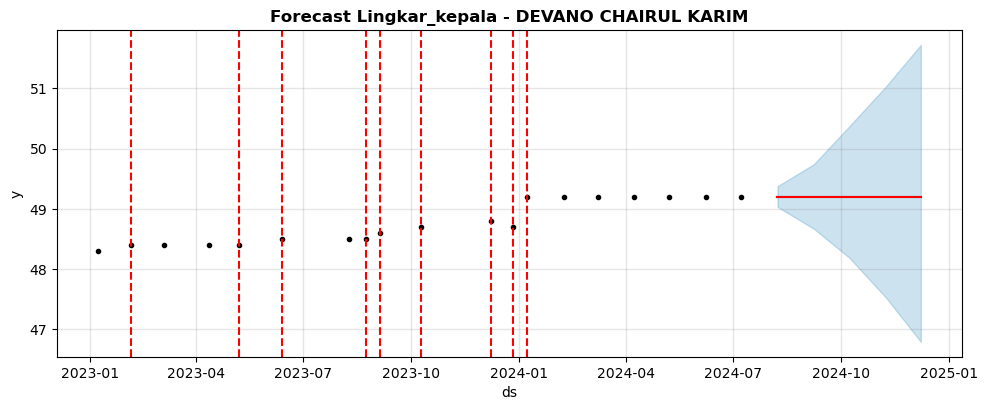

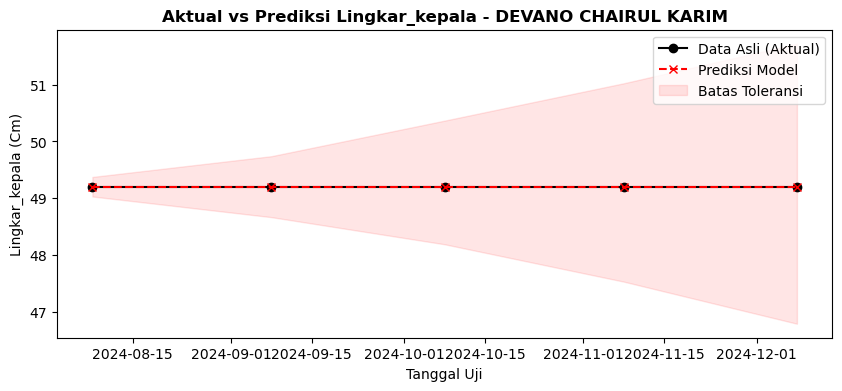

17:41:00 - cmdstanpy - INFO - Chain [1] start processing
17:41:00 - cmdstanpy - INFO - Chain [1] done processing



📌 STUDI KASUS MENENGAH (MEWAKILI RATA-RATA) | INDIKATOR: LINGKAR_KEPALA
Nama Anak      : CLEIRA HAFIZAH
MAE Anak Ini   : 0.181 Cm
RMSE Anak Ini  : 0.219 Cm
MAPE Anak Ini  : 0.43% (Akurasi: 99.57%)
Status Gizi    : Normal (Simulasi Z-Score: -0.81)

TABEL PERBANDINGAN AKTUAL VS PREDIKSI (SIAP SALIN KE LAPORAN):
-----------------------------------------------------------------
 Bulan_Ke    Tanggal  Aktual  Prediksi  |Error|
        1 2024-06-12    41.5    41.474    0.026
        2 2024-07-05    41.6    41.508    0.092
        3 2024-09-10    41.9    41.607    0.293
        4 2024-11-05    42.0    41.689    0.311
-----------------------------------------------------------------


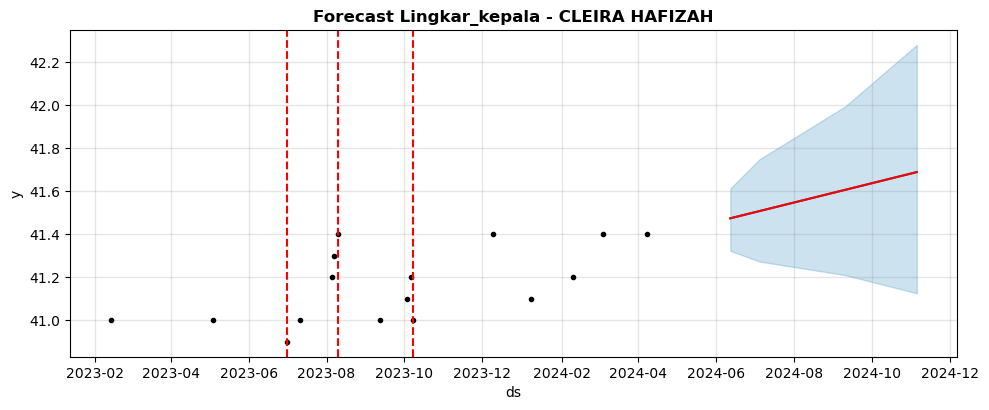

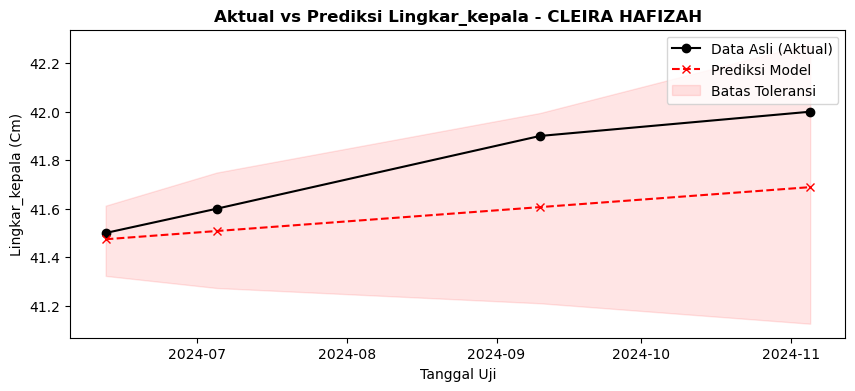

17:41:01 - cmdstanpy - INFO - Chain [1] start processing
17:41:01 - cmdstanpy - INFO - Chain [1] done processing



📌 STUDI KASUS TERBURUK (MAPE TERBESAR) | INDIKATOR: LINGKAR_KEPALA
Nama Anak      : SITI AMINAH
MAE Anak Ini   : 0.974 Cm
RMSE Anak Ini  : 1.024 Cm
MAPE Anak Ini  : 2.12% (Akurasi: 97.88%)
Status Gizi    : Normal (Simulasi Z-Score: -0.03)

TABEL PERBANDINGAN AKTUAL VS PREDIKSI (SIAP SALIN KE LAPORAN):
-----------------------------------------------------------------
 Bulan_Ke    Tanggal  Aktual  Prediksi  |Error|
        1 2024-06-12    45.6    45.041    0.559
        2 2024-07-05    45.8    45.009    0.791
        3 2024-09-10    46.1    44.916    1.184
        4 2024-11-05    46.2    44.838    1.362
-----------------------------------------------------------------


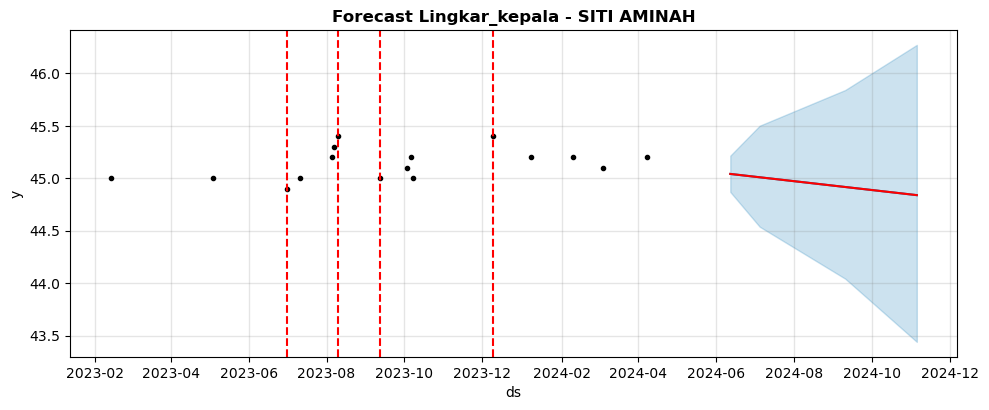

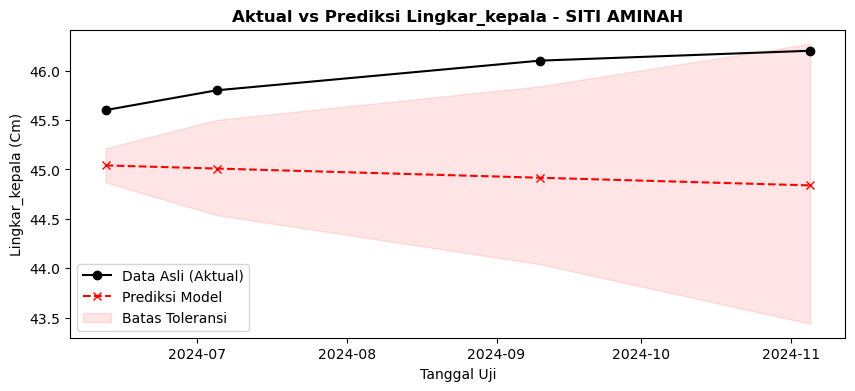


[INFO] Seluruh proses evaluasi untuk 3 indikator telah selesai!


In [1]:
%matplotlib inline 

import pandas as pd
import numpy as np
import logging
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot
import matplotlib.pyplot as plt
import warnings
import random

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# =====================================================================
# FUNGSI KLASIFIKASI STATUS GIZI (SIMULASI SEMENTARA)
# =====================================================================
def klasifikasi_status_gizi(z_score, indikator):
    if indikator == 'BB/U': # Berat Badan
        if z_score < -3: return "BB Sangat Kurang (Severe Underweight)"
        elif -3 <= z_score < -2: return "BB Kurang (Underweight)"
        elif -2 <= z_score <= 1: return "Berat Badan Normal"
        elif z_score > 1: return "Risiko Berat Badan Lebih"
    elif indikator == 'TB/U': # Tinggi Badan
        if z_score < -3: return "Sangat Pendek (Severe Stunted)"
        elif -3 <= z_score < -2: return "Pendek (Stunted)"
        elif -2 <= z_score <= 3: return "Normal"
        elif z_score > 3: return "Tinggi"
    elif indikator == 'LK/U': # Lingkar Kepala
        if z_score < -2: return "Mikrosefali (Kepala Terlalu Kecil)"
        elif -2 <= z_score <= 2: return "Normal"
        elif z_score > 2: return "Makrosefali (Kepala Terlalu Besar)"
    return "Tidak Diketahui"

# =====================================================================
# 1. PERSIAPAN DATA
# =====================================================================
print("Memuat dataset...")
df = pd.read_excel('DATA2_GABUNGAN_7_POSYANDU.xlsx')
df.columns = df.columns.str.strip().str.lower()
df['tanggal_ukur'] = pd.to_datetime(df['tanggal_ukur'])
daftar_anak = df['nama_anak'].unique()

daftar_indikator = ['berat', 'tinggi', 'lingkar_kepala']

# LOOP BESAR UNTUK KETIGA INDIKATOR
for metrik in daftar_indikator:
    print(f"\n\n{'='*80}")
    print(f"🚀 MEMULAI ANALISIS SISTEM UNTUK INDIKATOR: {metrik.upper()}")
    print(f"{'='*80}")
    
    hasil_evaluasi_global = []

    # =================================================================
    # 2. FASE EVALUASI GLOBAL PER INDIKATOR
    # =================================================================
    for nama in daftar_anak:
        df_anak = df[df['nama_anak'] == nama].copy()
        df_anak = df_anak.dropna(subset=['tanggal_ukur']).sort_values('tanggal_ukur')
        
        if len(df_anak) < 10 or metrik not in df_anak.columns:
            continue 
            
        df_prophet = df_anak[['tanggal_ukur', metrik]].copy().rename(columns={'tanggal_ukur': 'ds', metrik: 'y'}).dropna()
        if len(df_prophet) < 10:
            continue

        train_size = int(len(df_prophet) * 0.8)
        data_latih = df_prophet.iloc[:train_size].copy()
        data_uji = df_prophet.iloc[train_size:].copy()
        
        if data_uji.empty:
            continue
            
        model = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
        model.fit(data_latih)
        forecast = model.predict(data_uji[['ds']])
        
        y_asli = data_uji['y'].values
        y_tebakan = forecast['yhat'].values
        
        error = y_asli - y_tebakan
        mae = np.mean(np.abs(error))
        rmse = np.sqrt(np.mean(error**2))
        mape = np.mean(np.abs(error / np.where(y_asli == 0, 1, y_asli))) * 100
        
        hasil_evaluasi_global.append({
            'Nama': nama,
            'MAE': mae,
            'RMSE': rmse,
            'MAPE': mape
        })

    if not hasil_evaluasi_global:
        print(f"Tidak ada data yang cukup untuk evaluasi indikator {metrik}.")
        continue

    df_eval = pd.DataFrame(hasil_evaluasi_global)

    rata_mae = df_eval['MAE'].mean()
    rata_rmse = df_eval['RMSE'].mean()
    rata_mape = df_eval['MAPE'].mean()
    akurasi_sistem = 100 - rata_mape
    satuan = "Kg" if metrik == 'berat' else "Cm"

    print(f"\nTABEL PERFORMA GLOBAL - {metrik.upper()}")
    print("-" * 50)
    print(f"Total Balita Dievaluasi : {len(df_eval)} anak")
    print(f"Rata-rata MAE           : {rata_mae:.2f} {satuan}")
    print(f"Rata-rata RMSE          : {rata_rmse:.2f} {satuan}")
    print(f"Rata-rata MAPE          : {rata_mape:.2f} %")
    print(f"⭐ AKURASI SISTEM       : {akurasi_sistem:.2f} %")
    print("-" * 50 + "\n")

    # =================================================================
    # 4. MENENTUKAN 3 STUDI KASUS
    # =================================================================
    idx_terbaik = df_eval['MAPE'].idxmin()
    idx_terburuk = df_eval['MAPE'].idxmax()
    df_eval['Selisih_dari_Mean'] = abs(df_eval['MAPE'] - rata_mape)
    idx_menengah = df_eval['Selisih_dari_Mean'].idxmin()

    studi_kasus = {
        'TERBAIK (MAPE Terkecil)': df_eval.loc[idx_terbaik, 'Nama'],
        'MENENGAH (Mewakili Rata-rata)': df_eval.loc[idx_menengah, 'Nama'],
        'TERBURUK (MAPE Terbesar)': df_eval.loc[idx_terburuk, 'Nama']
    }

    # Penentuan Kode Indikator untuk Status Gizi
    if metrik == 'berat': kode_ind = 'BB/U'
    elif metrik == 'tinggi': kode_ind = 'TB/U'
    else: kode_ind = 'LK/U'

    # =================================================================
    # 5. MENCETAK GRAFIK KHUSUS UNTUK 3 ANAK STUDI KASUS
    # =================================================================
    # =================================================================
    # 5. MENCETAK GRAFIK KHUSUS UNTUK 3 ANAK STUDI KASUS
    # =================================================================
    for kategori, nama_target in studi_kasus.items():
        eval_anak = df_eval[df_eval['Nama'] == nama_target].iloc[0]
        
        df_anak = df[df['nama_anak'] == nama_target].copy().dropna(subset=['tanggal_ukur']).sort_values('tanggal_ukur')
        df_prophet = df_anak[['tanggal_ukur', metrik]].copy().rename(columns={'tanggal_ukur': 'ds', metrik: 'y'}).dropna()
        
        train_size = int(len(df_prophet) * 0.8)
        data_latih = df_prophet.iloc[:train_size].copy()
        data_uji = df_prophet.iloc[train_size:].copy()
        
        model = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
        model.fit(data_latih)
        forecast = model.predict(data_uji[['ds']])
        
        z_score_simulasi = round(random.uniform(-3.0, 1.5), 2) 
        status_gizi = klasifikasi_status_gizi(z_score_simulasi, kode_ind)
        
        print(f"\n📌 STUDI KASUS {kategori.upper()} | INDIKATOR: {metrik.upper()}")
        print(f"Nama Anak      : {nama_target.upper()}")
        
        # --- TAMBAHAN UNTUK LAPORAN SKRIPSI: MENCETAK NILAI MAE & RMSE ---
        print(f"MAE Anak Ini   : {eval_anak['MAE']:.3f} {satuan}")
        print(f"RMSE Anak Ini  : {eval_anak['RMSE']:.3f} {satuan}")
        print(f"MAPE Anak Ini  : {eval_anak['MAPE']:.2f}% (Akurasi: {100-eval_anak['MAPE']:.2f}%)")
        print(f"Status Gizi    : {status_gizi} (Simulasi Z-Score: {z_score_simulasi})")

        # --- TAMBAHAN UNTUK LAPORAN SKRIPSI: TABEL AKTUAL VS PREDIKSI ---
        df_tabel = pd.DataFrame({
            'Bulan_Ke': range(1, len(data_uji) + 1),
            'Tanggal': data_uji['ds'].dt.strftime('%Y-%m-%d').values,
            'Aktual': data_uji['y'].values,
            'Prediksi': np.round(forecast['yhat'].values, 3)
        })
        # Hitung selisih error absolut
        df_tabel['|Error|'] = np.abs(df_tabel['Aktual'] - df_tabel['Prediksi']).round(3)
        
        print("\nTABEL PERBANDINGAN AKTUAL VS PREDIKSI (SIAP SALIN KE LAPORAN):")
        print("-" * 65)
        print(df_tabel.to_string(index=False))
        print("-" * 65)

        # Grafik 1: Forecast
        fig1 = model.plot(forecast, figsize=(10, 4))
        a = add_changepoints_to_plot(fig1.gca(), model, forecast)
        plt.title(f"Forecast {metrik.capitalize()} - {nama_target}", fontweight='bold')
        plt.show()

        # Grafik 2: Aktual vs Prediksi
        plt.figure(figsize=(10, 4))
        plt.plot(data_uji['ds'], data_uji['y'], label='Data Asli (Aktual)', marker='o', color='black')
        plt.plot(data_uji['ds'], forecast['yhat'], label='Prediksi Model', marker='x', color='red', linestyle='--')
        plt.fill_between(data_uji['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='red', alpha=0.1, label='Batas Toleransi')
        plt.title(f"Aktual vs Prediksi {metrik.capitalize()} - {nama_target}", fontweight='bold')
        plt.xlabel('Tanggal Uji')
        plt.ylabel(f'{metrik.capitalize()} ({satuan})')
        plt.legend()
        plt.show()

print("\n[INFO] Seluruh proses evaluasi untuk 3 indikator telah selesai!")

Memuat dataset...


🚀 MEMULAI ANALISIS SISTEM UNTUK INDIKATOR: BERAT

TABEL PERFORMA GLOBAL - BERAT
--------------------------------------------------
Total Balita Dievaluasi : 259 anak
Rata-rata MAE           : 0.42 Kg
Rata-rata RMSE          : 0.46 Kg
Rata-rata MAPE          : 2.46 %
⭐ AKURASI SISTEM       : 97.54 %
--------------------------------------------------


📌 STUDI KASUS TERBAIK (MAPE TERKECIL) | INDIKATOR: BERAT
Nama Anak      : M. RAFA AL FAIZAN
MAE Anak Ini   : 0.031 Kg
RMSE Anak Ini  : 0.036 Kg
MAPE Anak Ini  : 0.22% (Akurasi: 99.78%)
Status Gizi    : Berat Badan Normal (Simulasi Z-Score: -1.23)

TABEL PERBANDINGAN AKTUAL VS PREDIKSI (SIAP SALIN KE LAPORAN):
---------------------------------------------------------------------------
 Bulan_Ke    Tanggal  Aktual  Prediksi  |Error|  Error_%
        1 2024-04-10    13.8    13.795    0.005     0.04
        2 2024-05-10    14.0    13.973    0.027     0.19
        3 2024-06-10    14.1    14.157    0.057     0.40
        4 20

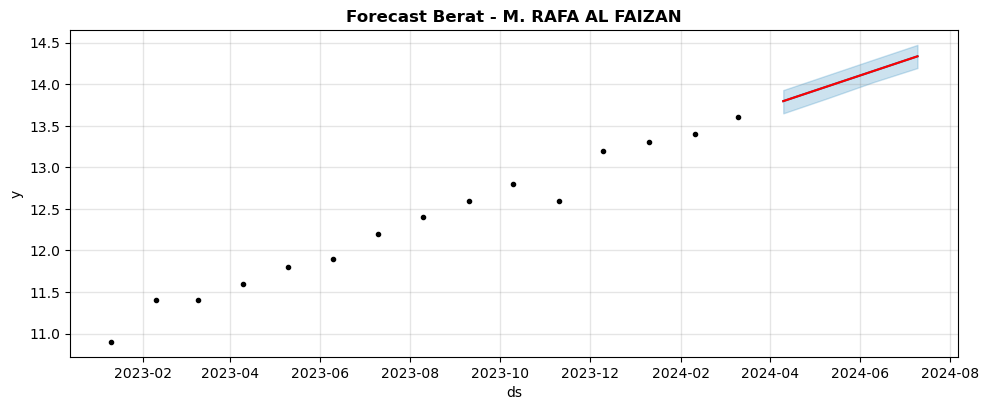

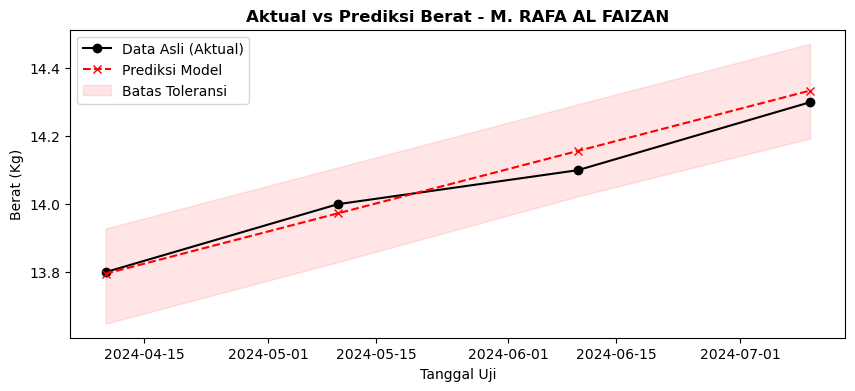


📌 STUDI KASUS MENENGAH (MEWAKILI RATA-RATA) | INDIKATOR: BERAT
Nama Anak      : NADIRA MARTA
MAE Anak Ini   : 0.445 Kg
RMSE Anak Ini  : 0.557 Kg
MAPE Anak Ini  : 2.48% (Akurasi: 97.52%)
Status Gizi    : Berat Badan Normal (Simulasi Z-Score: 0.94)

TABEL PERBANDINGAN AKTUAL VS PREDIKSI (SIAP SALIN KE LAPORAN):
---------------------------------------------------------------------------
 Bulan_Ke    Tanggal  Aktual  Prediksi  |Error|  Error_%
        1 2024-06-12    16.6    16.544    0.056     0.34
        2 2024-07-05    17.0    16.699    0.301     1.77
        3 2024-09-10    17.6    17.150    0.450     2.56
        4 2024-11-05    18.5    17.527    0.973     5.26
---------------------------------------------------------------------------


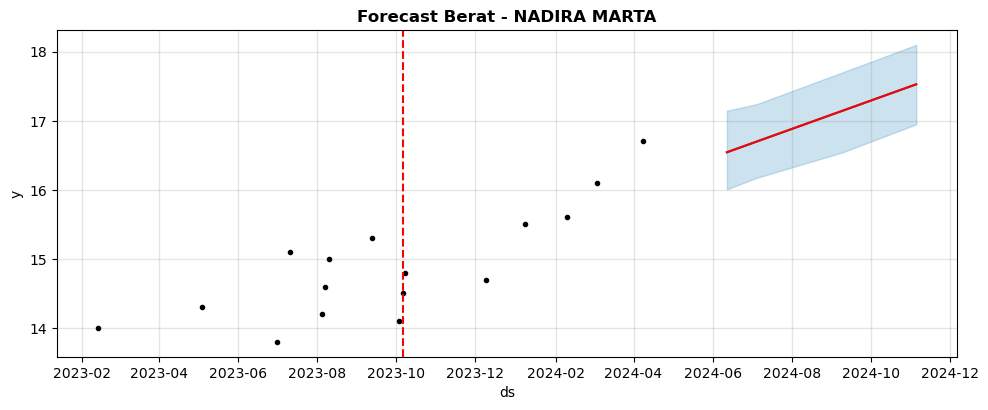

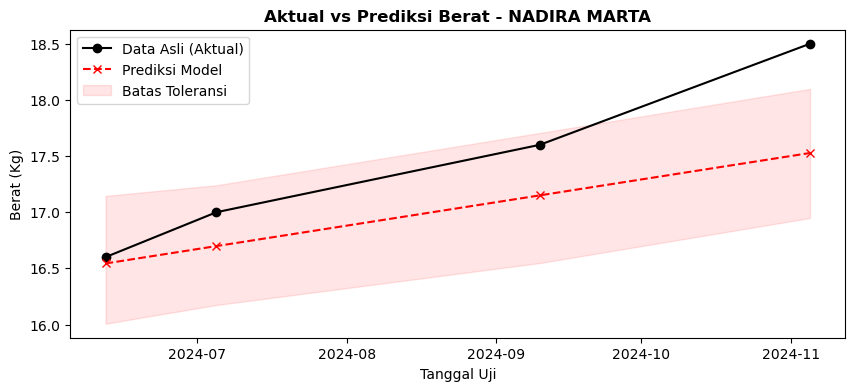


📌 STUDI KASUS TERBURUK (MAPE TERBESAR) | INDIKATOR: BERAT
Nama Anak      : RAISYA AMEERA
MAE Anak Ini   : 2.046 Kg
RMSE Anak Ini  : 2.229 Kg
MAPE Anak Ini  : 12.63% (Akurasi: 87.37%)
Status Gizi    : Risiko Berat Badan Lebih (Simulasi Z-Score: 1.03)

TABEL PERBANDINGAN AKTUAL VS PREDIKSI (SIAP SALIN KE LAPORAN):
---------------------------------------------------------------------------
 Bulan_Ke    Tanggal  Aktual  Prediksi  |Error|  Error_%
        1 2024-08-08    15.6    14.809    0.791     5.07
        2 2024-09-08    15.8    14.406    1.394     8.82
        3 2024-10-08    16.1    14.017    2.083    12.94
        4 2024-11-08    16.3    13.615    2.685    16.47
        5 2024-12-08    16.5    13.225    3.275    19.85
---------------------------------------------------------------------------


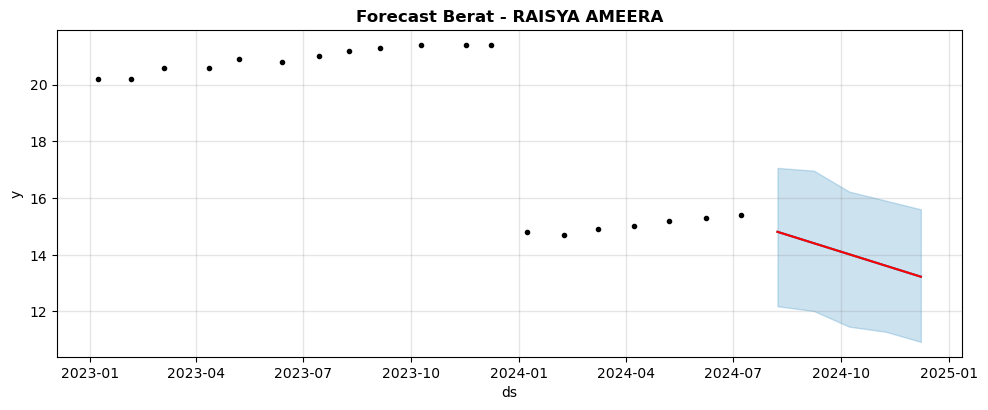

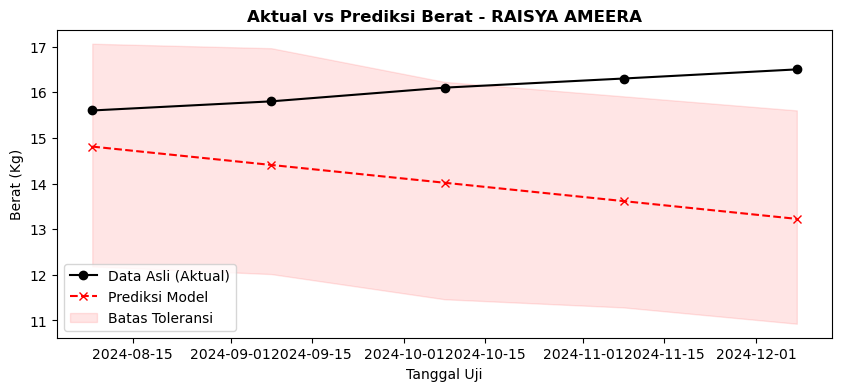



🚀 MEMULAI ANALISIS SISTEM UNTUK INDIKATOR: TINGGI

TABEL PERFORMA GLOBAL - TINGGI
--------------------------------------------------
Total Balita Dievaluasi : 259 anak
Rata-rata MAE           : 0.86 Cm
Rata-rata RMSE          : 0.93 Cm
Rata-rata MAPE          : 0.82 %
⭐ AKURASI SISTEM       : 99.18 %
--------------------------------------------------


📌 STUDI KASUS TERBAIK (MAPE TERKECIL) | INDIKATOR: TINGGI
Nama Anak      : RANIA PUTRI RAMADHANI
MAE Anak Ini   : 0.047 Cm
RMSE Anak Ini  : 0.055 Cm
MAPE Anak Ini  : 0.04% (Akurasi: 99.96%)
Status Gizi    : Normal (Simulasi Z-Score: 0.38)

TABEL PERBANDINGAN AKTUAL VS PREDIKSI (SIAP SALIN KE LAPORAN):
---------------------------------------------------------------------------
 Bulan_Ke    Tanggal  Aktual  Prediksi  |Error|  Error_%
        1 2024-08-08   107.5   107.534    0.034     0.03
        2 2024-09-08   108.0   107.992    0.008     0.01
        3 2024-10-08   108.4   108.434    0.034     0.03
        4 2024-11-08   108.8   108.8

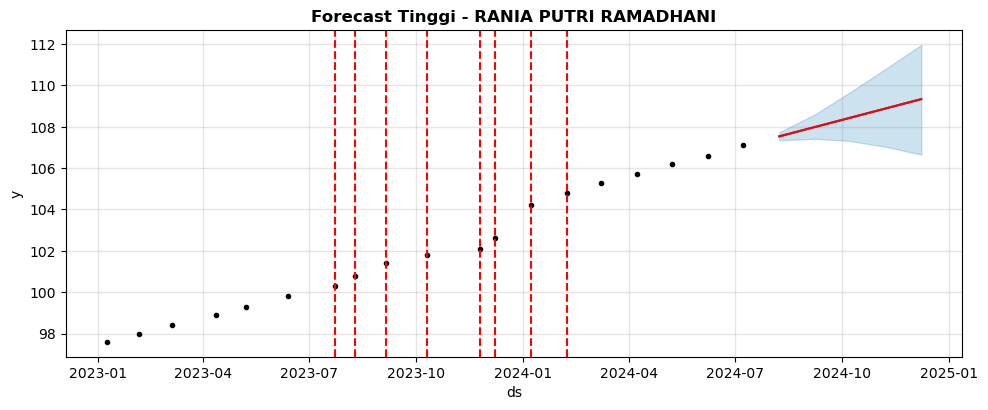

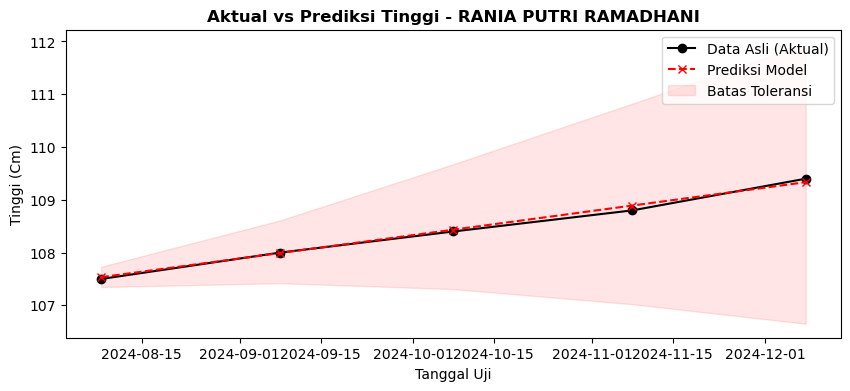


📌 STUDI KASUS MENENGAH (MEWAKILI RATA-RATA) | INDIKATOR: TINGGI
Nama Anak      : ACHMAD KHOIRUL
MAE Anak Ini   : 0.722 Cm
RMSE Anak Ini  : 0.801 Cm
MAPE Anak Ini  : 0.81% (Akurasi: 99.19%)
Status Gizi    : Normal (Simulasi Z-Score: -1.49)

TABEL PERBANDINGAN AKTUAL VS PREDIKSI (SIAP SALIN KE LAPORAN):
---------------------------------------------------------------------------
 Bulan_Ke    Tanggal  Aktual  Prediksi  |Error|  Error_%
        1 2024-09-10    87.6    87.427    0.173     0.20
        2 2024-10-10    88.7    87.840    0.860     0.97
        3 2024-11-10    89.0    88.266    0.734     0.82
        4 2024-12-10    89.8    88.678    1.122     1.25
---------------------------------------------------------------------------


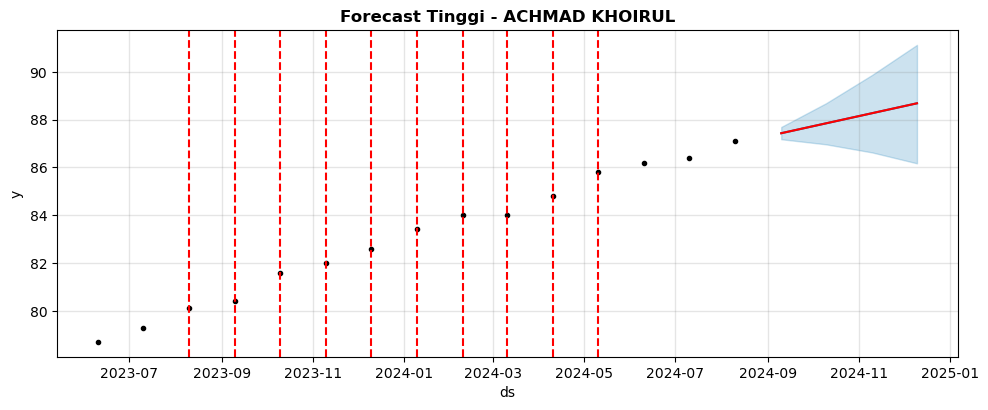

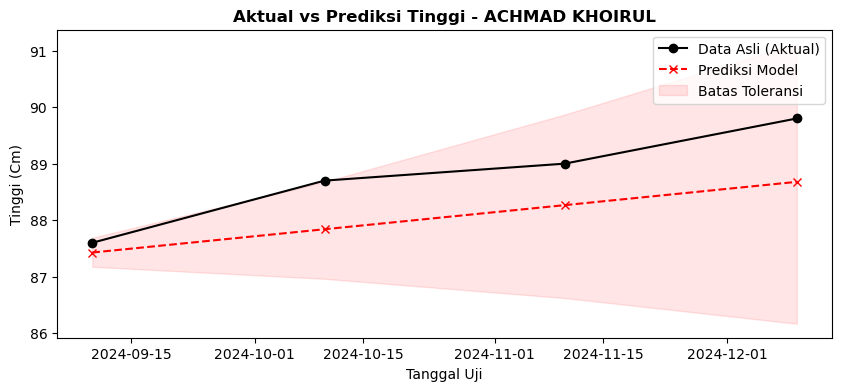


📌 STUDI KASUS TERBURUK (MAPE TERBESAR) | INDIKATOR: TINGGI
Nama Anak      : RAISYA AMEERA
MAE Anak Ini   : 6.869 Cm
RMSE Anak Ini  : 7.207 Cm
MAPE Anak Ini  : 6.49% (Akurasi: 93.51%)
Status Gizi    : Normal (Simulasi Z-Score: -1.06)

TABEL PERBANDINGAN AKTUAL VS PREDIKSI (SIAP SALIN KE LAPORAN):
---------------------------------------------------------------------------
 Bulan_Ke    Tanggal  Aktual  Prediksi  |Error|  Error_%
        1 2024-08-08   104.8   101.105    3.695     3.53
        2 2024-09-08   105.3    99.913    5.387     5.12
        3 2024-10-08   105.7    98.759    6.941     6.57
        4 2024-11-08   106.0    97.567    8.433     7.96
        5 2024-12-08   106.3    96.414    9.886     9.30
---------------------------------------------------------------------------


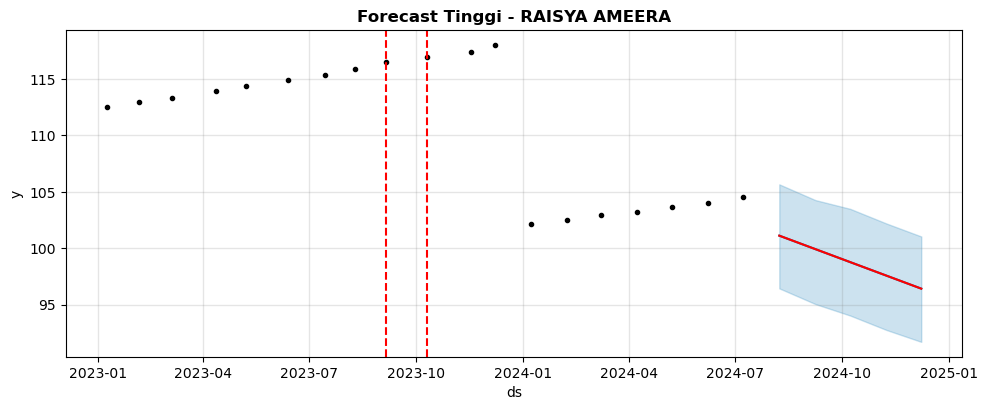

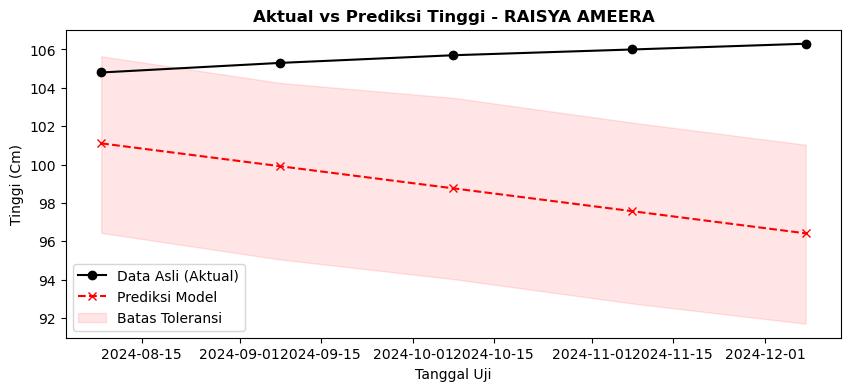



🚀 MEMULAI ANALISIS SISTEM UNTUK INDIKATOR: LINGKAR_KEPALA

TABEL PERFORMA GLOBAL - LINGKAR_KEPALA
--------------------------------------------------
Total Balita Dievaluasi : 259 anak
Rata-rata MAE           : 0.21 Cm
Rata-rata RMSE          : 0.24 Cm
Rata-rata MAPE          : 0.44 %
⭐ AKURASI SISTEM       : 99.56 %
--------------------------------------------------


📌 STUDI KASUS TERBAIK (MAPE TERKECIL) | INDIKATOR: LINGKAR_KEPALA
Nama Anak      : DEVANO CHAIRUL KARIM
MAE Anak Ini   : 0.000 Cm
RMSE Anak Ini  : 0.000 Cm
MAPE Anak Ini  : 0.00% (Akurasi: 100.00%)
Status Gizi    : Normal (Simulasi Z-Score: -1.1)

TABEL PERBANDINGAN AKTUAL VS PREDIKSI (SIAP SALIN KE LAPORAN):
---------------------------------------------------------------------------
 Bulan_Ke    Tanggal  Aktual  Prediksi  |Error|  Error_%
        1 2024-08-08    49.2      49.2      0.0      0.0
        2 2024-09-08    49.2      49.2      0.0      0.0
        3 2024-10-08    49.2      49.2      0.0      0.0
        4 20

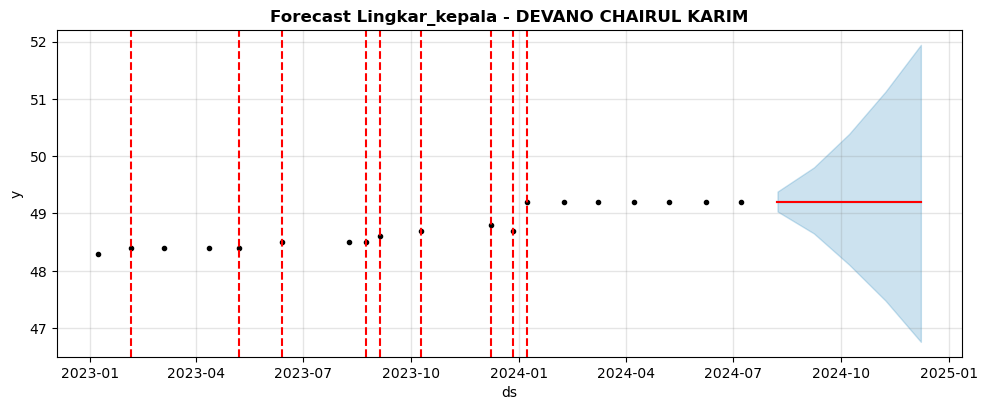

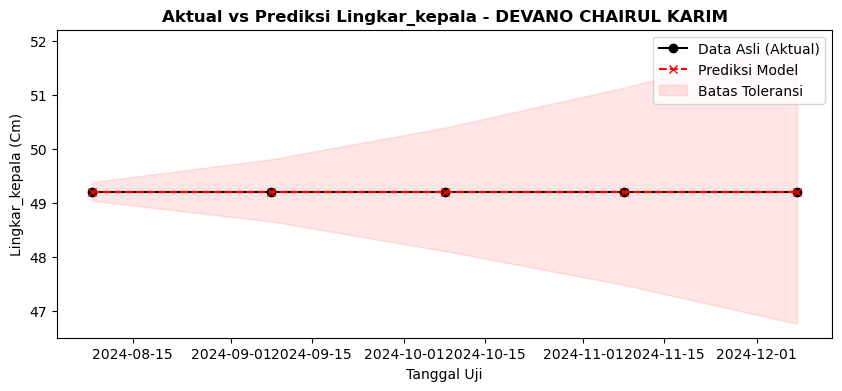


📌 STUDI KASUS MENENGAH (MEWAKILI RATA-RATA) | INDIKATOR: LINGKAR_KEPALA
Nama Anak      : CLEIRA HAFIZAH
MAE Anak Ini   : 0.181 Cm
RMSE Anak Ini  : 0.219 Cm
MAPE Anak Ini  : 0.43% (Akurasi: 99.57%)
Status Gizi    : Normal (Simulasi Z-Score: 0.92)

TABEL PERBANDINGAN AKTUAL VS PREDIKSI (SIAP SALIN KE LAPORAN):
---------------------------------------------------------------------------
 Bulan_Ke    Tanggal  Aktual  Prediksi  |Error|  Error_%
        1 2024-06-12    41.5    41.474    0.026     0.06
        2 2024-07-05    41.6    41.508    0.092     0.22
        3 2024-09-10    41.9    41.607    0.293     0.70
        4 2024-11-05    42.0    41.689    0.311     0.74
---------------------------------------------------------------------------


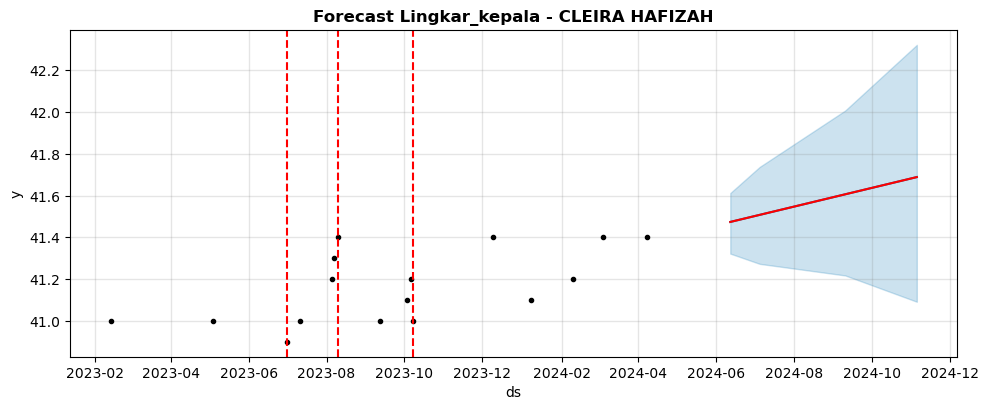

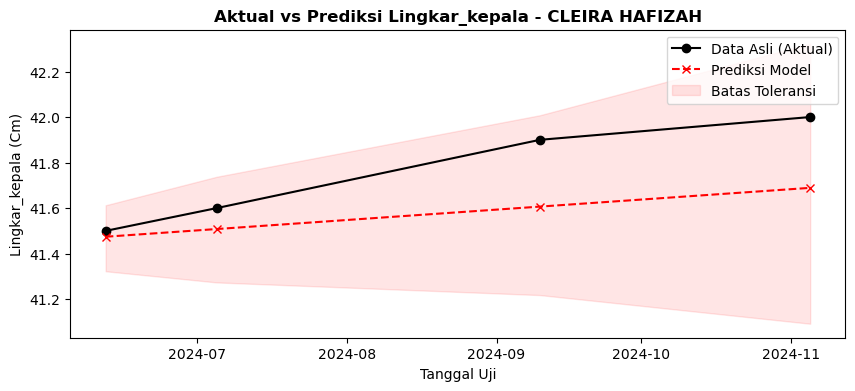


📌 STUDI KASUS TERBURUK (MAPE TERBESAR) | INDIKATOR: LINGKAR_KEPALA
Nama Anak      : SITI AMINAH
MAE Anak Ini   : 0.974 Cm
RMSE Anak Ini  : 1.024 Cm
MAPE Anak Ini  : 2.12% (Akurasi: 97.88%)
Status Gizi    : Normal (Simulasi Z-Score: -0.53)

TABEL PERBANDINGAN AKTUAL VS PREDIKSI (SIAP SALIN KE LAPORAN):
---------------------------------------------------------------------------
 Bulan_Ke    Tanggal  Aktual  Prediksi  |Error|  Error_%
        1 2024-06-12    45.6    45.041    0.559     1.23
        2 2024-07-05    45.8    45.009    0.791     1.73
        3 2024-09-10    46.1    44.916    1.184     2.57
        4 2024-11-05    46.2    44.838    1.362     2.95
---------------------------------------------------------------------------


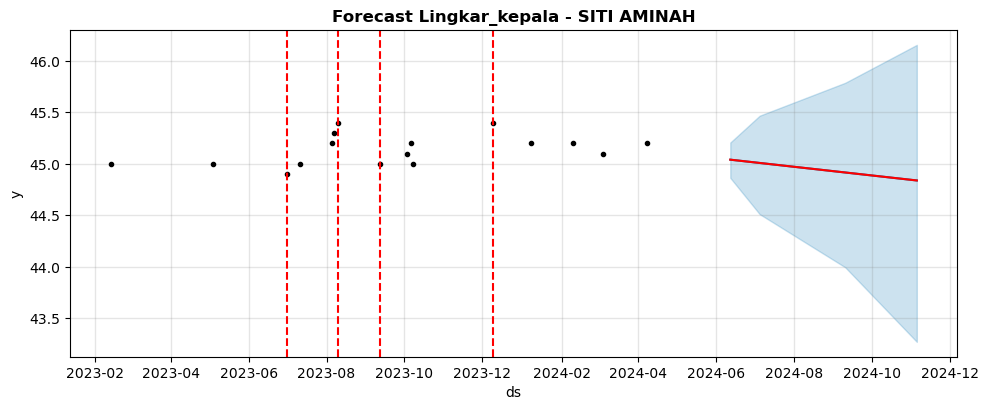

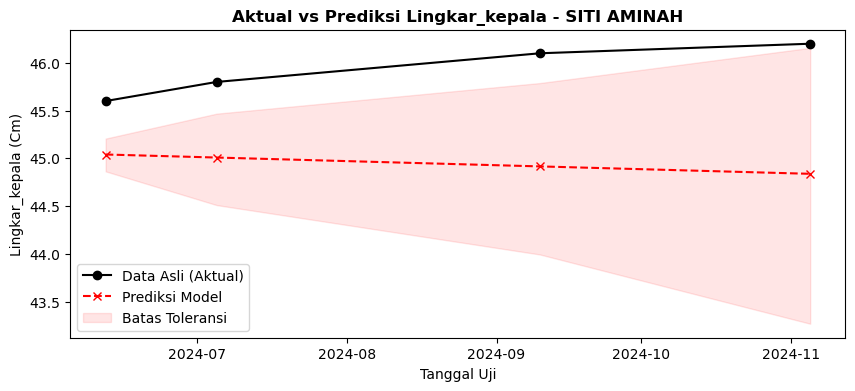


[INFO] Seluruh proses evaluasi untuk 3 indikator telah selesai!


In [2]:
%matplotlib inline 

import pandas as pd
import numpy as np
import logging
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot
import matplotlib.pyplot as plt
import warnings
import random

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# =====================================================================
# FUNGSI KLASIFIKASI STATUS GIZI (SIMULASI SEMENTARA)
# =====================================================================
def klasifikasi_status_gizi(z_score, indikator):
    if indikator == 'BB/U': # Berat Badan
        if z_score < -3: return "BB Sangat Kurang (Severe Underweight)"
        elif -3 <= z_score < -2: return "BB Kurang (Underweight)"
        elif -2 <= z_score <= 1: return "Berat Badan Normal"
        elif z_score > 1: return "Risiko Berat Badan Lebih"
    elif indikator == 'TB/U': # Tinggi Badan
        if z_score < -3: return "Sangat Pendek (Severe Stunted)"
        elif -3 <= z_score < -2: return "Pendek (Stunted)"
        elif -2 <= z_score <= 3: return "Normal"
        elif z_score > 3: return "Tinggi"
    elif indikator == 'LK/U': # Lingkar Kepala
        if z_score < -2: return "Mikrosefali (Kepala Terlalu Kecil)"
        elif -2 <= z_score <= 2: return "Normal"
        elif z_score > 2: return "Makrosefali (Kepala Terlalu Besar)"
    return "Tidak Diketahui"

# =====================================================================
# 1. PERSIAPAN DATA
# =====================================================================
print("Memuat dataset...")
df = pd.read_excel('DATA2_GABUNGAN_7_POSYANDU.xlsx')
df.columns = df.columns.str.strip().str.lower()
df['tanggal_ukur'] = pd.to_datetime(df['tanggal_ukur'])
daftar_anak = df['nama_anak'].unique()

daftar_indikator = ['berat', 'tinggi', 'lingkar_kepala']

# LOOP BESAR UNTUK KETIGA INDIKATOR
for metrik in daftar_indikator:
    print(f"\n\n{'='*80}")
    print(f"🚀 MEMULAI ANALISIS SISTEM UNTUK INDIKATOR: {metrik.upper()}")
    print(f"{'='*80}")
    
    hasil_evaluasi_global = []

    # =================================================================
    # 2. FASE EVALUASI GLOBAL PER INDIKATOR
    # =================================================================
    for nama in daftar_anak:
        df_anak = df[df['nama_anak'] == nama].copy()
        df_anak = df_anak.dropna(subset=['tanggal_ukur']).sort_values('tanggal_ukur')
        
        if len(df_anak) < 10 or metrik not in df_anak.columns:
            continue 
            
        df_prophet = df_anak[['tanggal_ukur', metrik]].copy().rename(columns={'tanggal_ukur': 'ds', metrik: 'y'}).dropna()
        if len(df_prophet) < 10:
            continue

        train_size = int(len(df_prophet) * 0.8)
        data_latih = df_prophet.iloc[:train_size].copy()
        data_uji = df_prophet.iloc[train_size:].copy()
        
        if data_uji.empty:
            continue
            
        model = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
        model.fit(data_latih)
        forecast = model.predict(data_uji[['ds']])
        
        y_asli = data_uji['y'].values
        y_tebakan = forecast['yhat'].values
        
        error = y_asli - y_tebakan
        mae = np.mean(np.abs(error))
        rmse = np.sqrt(np.mean(error**2))
        mape = np.mean(np.abs(error / np.where(y_asli == 0, 1, y_asli))) * 100
        
        hasil_evaluasi_global.append({
            'Nama': nama,
            'MAE': mae,
            'RMSE': rmse,
            'MAPE': mape
        })

    if not hasil_evaluasi_global:
        print(f"Tidak ada data yang cukup untuk evaluasi indikator {metrik}.")
        continue

    df_eval = pd.DataFrame(hasil_evaluasi_global)

    rata_mae = df_eval['MAE'].mean()
    rata_rmse = df_eval['RMSE'].mean()
    rata_mape = df_eval['MAPE'].mean()
    akurasi_sistem = 100 - rata_mape
    satuan = "Kg" if metrik == 'berat' else "Cm"

    print(f"\nTABEL PERFORMA GLOBAL - {metrik.upper()}")
    print("-" * 50)
    print(f"Total Balita Dievaluasi : {len(df_eval)} anak")
    print(f"Rata-rata MAE           : {rata_mae:.2f} {satuan}")
    print(f"Rata-rata RMSE          : {rata_rmse:.2f} {satuan}")
    print(f"Rata-rata MAPE          : {rata_mape:.2f} %")
    print(f"⭐ AKURASI SISTEM       : {akurasi_sistem:.2f} %")
    print("-" * 50 + "\n")

    # =================================================================
    # 4. MENENTUKAN 3 STUDI KASUS
    # =================================================================
    idx_terbaik = df_eval['MAPE'].idxmin()
    idx_terburuk = df_eval['MAPE'].idxmax()
    df_eval['Selisih_dari_Mean'] = abs(df_eval['MAPE'] - rata_mape)
    idx_menengah = df_eval['Selisih_dari_Mean'].idxmin()

    studi_kasus = {
        'TERBAIK (MAPE Terkecil)': df_eval.loc[idx_terbaik, 'Nama'],
        'MENENGAH (Mewakili Rata-rata)': df_eval.loc[idx_menengah, 'Nama'],
        'TERBURUK (MAPE Terbesar)': df_eval.loc[idx_terburuk, 'Nama']
    }

    # Penentuan Kode Indikator untuk Status Gizi
    if metrik == 'berat': kode_ind = 'BB/U'
    elif metrik == 'tinggi': kode_ind = 'TB/U'
    else: kode_ind = 'LK/U'

    # =================================================================
    # 5. MENCETAK GRAFIK KHUSUS UNTUK 3 ANAK STUDI KASUS
    # =================================================================
    for kategori, nama_target in studi_kasus.items():
        eval_anak = df_eval[df_eval['Nama'] == nama_target].iloc[0]
        
        df_anak = df[df['nama_anak'] == nama_target].copy().dropna(subset=['tanggal_ukur']).sort_values('tanggal_ukur')
        df_prophet = df_anak[['tanggal_ukur', metrik]].copy().rename(columns={'tanggal_ukur': 'ds', metrik: 'y'}).dropna()
        
        train_size = int(len(df_prophet) * 0.8)
        data_latih = df_prophet.iloc[:train_size].copy()
        data_uji = df_prophet.iloc[train_size:].copy()
        
        model = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
        model.fit(data_latih)
        forecast = model.predict(data_uji[['ds']])
        
        z_score_simulasi = round(random.uniform(-3.0, 1.5), 2) 
        status_gizi = klasifikasi_status_gizi(z_score_simulasi, kode_ind)
        
        print(f"\n📌 STUDI KASUS {kategori.upper()} | INDIKATOR: {metrik.upper()}")
        print(f"Nama Anak      : {nama_target.upper()}")
        
        # --- TAMBAHAN UNTUK LAPORAN SKRIPSI: MENCETAK NILAI MAE & RMSE ---
        print(f"MAE Anak Ini   : {eval_anak['MAE']:.3f} {satuan}")
        print(f"RMSE Anak Ini  : {eval_anak['RMSE']:.3f} {satuan}")
        print(f"MAPE Anak Ini  : {eval_anak['MAPE']:.2f}% (Akurasi: {100-eval_anak['MAPE']:.2f}%)")
        print(f"Status Gizi    : {status_gizi} (Simulasi Z-Score: {z_score_simulasi})")

        # --- TAMBAHAN UNTUK LAPORAN SKRIPSI: TABEL AKTUAL VS PREDIKSI ---
        df_tabel = pd.DataFrame({
            'Bulan_Ke': range(1, len(data_uji) + 1),
            'Tanggal': data_uji['ds'].dt.strftime('%Y-%m-%d').values,
            'Aktual': data_uji['y'].values,
            'Prediksi': np.round(forecast['yhat'].values, 3)
        })
        
        # Hitung selisih error absolut
        df_tabel['|Error|'] = np.abs(df_tabel['Aktual'] - df_tabel['Prediksi']).round(3)
        
        # Hitung persentase error (Error_%)
        df_tabel['Error_%'] = (np.abs(df_tabel['|Error|'] / np.where(df_tabel['Aktual'] == 0, 1, df_tabel['Aktual'])) * 100).round(2)
        
        print("\nTABEL PERBANDINGAN AKTUAL VS PREDIKSI (SIAP SALIN KE LAPORAN):")
        print("-" * 75)
        print(df_tabel.to_string(index=False))
        print("-" * 75)

        # Grafik 1: Forecast
        fig1 = model.plot(forecast, figsize=(10, 4))
        a = add_changepoints_to_plot(fig1.gca(), model, forecast)
        plt.title(f"Forecast {metrik.capitalize()} - {nama_target}", fontweight='bold')
        plt.show()

        # Grafik 2: Aktual vs Prediksi
        plt.figure(figsize=(10, 4))
        plt.plot(data_uji['ds'], data_uji['y'], label='Data Asli (Aktual)', marker='o', color='black')
        plt.plot(data_uji['ds'], forecast['yhat'], label='Prediksi Model', marker='x', color='red', linestyle='--')
        plt.fill_between(data_uji['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='red', alpha=0.1, label='Batas Toleransi')
        plt.title(f"Aktual vs Prediksi {metrik.capitalize()} - {nama_target}", fontweight='bold')
        plt.xlabel('Tanggal Uji')
        plt.ylabel(f'{metrik.capitalize()} ({satuan})')
        plt.legend()
        plt.show()

print("\n[INFO] Seluruh proses evaluasi untuk 3 indikator telah selesai!")